# **Análisis global de factores asociados a la felicidad**

### Carlos F. Carreras De León

El **objetivo general** es identificar factores alternativos a los ya establecidos por la teoría que predigan a nivel mundial la felicidad, incluyendo variables individuales y agregadas, por medio de un modelo predictivo de aprendizaje automático que se destaque encontrando relaciones no lineales, utilizando datos transversales de la última Encuesta Mundial de Valores.

El **objetivo específico** es describir la correlación entre felicidad y cuatro variables agregadas de interés macroeconómico e impacto político que son el PIB per cápita, el índice de Gini, el índice de percepción de corrupción y la tasa de desempleo, mediante un análisis visual de gráficos de dispersión, desde una perspectiva regional, utilizando datos del Banco Mundial y Transparencia Internacional.




## **Preparación de los datos**

Montar al drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importación de librerías

In [ ]:
# Librerias de manipulación de datos
import pandas as pd
import numpy as np

#Librerías de visualización de datos
import seaborn as sns
import matplotlib.pyplot as plt

#Libreria de Scipy.stats para análisis estadísticos
from scipy.stats import pearsonr, spearmanr

# Librerías de Scikit-learn para modelado de aprendizaje automaático
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

El conjunto de datos corresponde a la **Encuesta Mundial de Valores (World Value Survey)** que entrevista miles de individuos de diferentes países cada cierto tiempo sobre sus sentimientos, opiniones y percepciones de una variedad de temas sociales, políticos, económicos, religiosos, morales, laborales, vida familiar, vida social, seguridad, científicos, ambientales y culturales. Cuenta con 1,046 variables que implica una alta dimensionalidad. En su gran mayoría las preguntas son cerradas y cualitativas (categóricas nominales y ordinales con escala de Likert). Para entender la codificación de cada una se consultó el listado de variables que puede descargarse del sitio web de WVS (https://www.worldvaluessurvey.org/WVSDocumentationWVL.jsp). En Excel se hizo un procesamiento previo seleccionando solamente las filas que corresponden a la última ola de la encuesta (wave 7) que se desarrolló entre 2017 y 2023, ya que la memoria del Google Colab no permitía subir la encuesta completa que viene haciéndose desde 1981.

Este data set que se carga ya tiene integrado cuatro columnas o variables agregadas cuyos datos provienen de otras fuentes: Banco Mundial y Transparencia Internacional. Esas nuevas columnas son: PIB per cápita, Tasa de Desempleo, Índice de Percepción de Corrupción y Coeficiente de Gini. Había algunos países que no tenían disponible este tipo de estadísticas oficiales o estaban muy desactualizadas por lo que tuvieron que eliminarse de la muestra para reducir el ruido: Puerto Rico, Andorra, Irlanda del Norte, Macao, Hong Kong, Jordania, Nicaragua, Libia y Marruecos. De un total de 66 países se redujo la muestra a 57. También se crearon previamente las variables País y Región Geográfica, ya que el data set original sólo incluía el código ISO de tres letras del país.

In [ ]:
#Carga de los datos
datos = pd.read_csv("/content/drive/MyDrive/WVS_2017-2023.csv")

# Dimensiones del data set
print("Dimensiones:", datos.shape)

# Primeras cinco filas del data set
datos.head()

/tmp/ipykernel_2418/3054831491.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  datos = pd.read_csv("/content/drive/MyDrive/WVS_2017-2023.csv")


Dimensiones: (86745, 1052)


,version,doi,S001,S002VS,S003,COUNTRY_ALPHA,COW_NUM,COW_ALPHA,PAÍS,REGION,...,Y023A,Y023B,Y023C,Y024A,Y024B,Y024C,survself,tradrat5,TradAgg,SurvSAgg
0,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,840,USA,2,USA,Estados Unidos,América del Norte,...,0.444444,0.111111,0.444444,0.00,0.0,0.000,0.019969,0.131891,0.112344,0.074143
1,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,840,USA,2,USA,Estados Unidos,América del Norte,...,0.444444,0.888889,0.666667,1.00,0.5,0.750,0.681721,-0.048471,-0.178039,1.271915
2,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,840,USA,2,USA,Estados Unidos,América del Norte,...,1.000000,0.888889,0.888889,0.33,1.0,0.665,2.557429,0.036877,-0.040628,4.666947
3,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,840,USA,2,USA,Estados Unidos,América del Norte,...,0.000000,0.111111,0.444444,0.33,0.0,0.165,0.769598,-0.558926,-0.999871,1.430972
4,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,840,USA,2,USA,Estados Unidos,América del Norte,...,0.555556,0.555556,0.666667,1.00,0.0,0.500,1.811794,-0.274140,-0.541365,3.317347


In [ ]:
# Información general del data set
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86745 entries, 0 to 86744
Columns: 1052 entries, version to SurvSAgg
dtypes: float64(47), int64(998), object(7)
memory usage: 696.2+ MB


El data set tiene 86,745 filas y 1,052 columnas de las cuales 47 son numéricas decimales, 998 numéricas enteros y 7 de tipo texto.

### Transformación de variables

Crear una copia del data frame orginal

In [ ]:
copia_datos = datos.copy()

Renombrar algunas variables claves de análisis

In [ ]:
columnas_a_renombrar = {
    'V097EF': 'ocupación_padre',
    'V004AF_01': 'educ_padre',
    'V004AM_01': 'educ_madre',
    'X051': 'etnia',
    'W002A_01': 'educ_esposo',
    'W003': 'estatuslaboral_esposo',
    'W006E': 'ocupación_esposo',
    'X036E': 'ocupación',
    'X045': 'clasesocial',
    'X047_WVS': 'nivelingresos',
    'X040': 'jefehogar',
    'X026': 'viveconpadres',
    'X028': 'estatuslaboral',
    'X025A_01': 'educ',
    'X013': 'tamañohogar',
    'X007': 'estadocivil',
    'PAÍS': 'País',
    'X001':'sexo',
    'X003': 'edad',
    'X003R': 'grupoetario',
    'A170': 'satisfacciónvital',
    'REGION': 'Región',
    'A009':'estadodesalud',
    'C006':'satisfacciónfinanciera',
    'A173':'libertaddeelección',
    'E276':'impunidadsoborno',
    'E277':'movilidadeconómica',
    'H008_01':'escasezalimentos',
    'H008_02':'seguridadciudadana',
    'H008_03':'escasezmedicinas',
    'H008_04':'escasezdinero',
    'H001':'barrioseguro',
    'E124':'respetoDDHH',
    'E234':'tecnología',
    'E236':'democracia',
    'G006':'orgullonacional',
    'E040':'valordeltrabajo',
    'E035':'desigualdadingresos',
    'E037':'responsabilidadgobierno',
    'E069_07':'confianzaparlamento',
    'E069_11':'confianzagobierno',
    'E069_41':'confianzabancos',
    'E274':'frecuenciasoborno',
    'D001_B':'confianzafamilia',
    'I002':'ignoranciacientífica',
    'X050C': 'tipohogar',
}

# Filtrar solo las columnas que existen en el DataFrame
existing_columns_to_rename = {old_name: new_name for old_name, new_name in columnas_a_renombrar.items() if old_name in copia_datos.columns}

if existing_columns_to_rename:
    copia_datos.rename(columns=existing_columns_to_rename, inplace=True)
    print("Columnas renombradas exitosamente.")
    print("Primeras 5 filas del DataFrame con las columnas renombradas:")
    print(copia_datos.head())
else:
    print("Ninguna de las columnas especificadas para renombrar se encontró en el DataFrame.")

Columnas renombradas exitosamente.
Primeras 5 filas del DataFrame con las columnas renombradas:
              version                        doi  S001  S002VS  S003  \
0  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       7   840   
1  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       7   840   
2  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       7   840   
3  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       7   840   
4  5-0-0 (2024-04-30)  doi.org/10.14281/18241.25     2       7   840   

  COUNTRY_ALPHA  COW_NUM COW_ALPHA            País             Región  ...  \
0           USA        2       USA  Estados Unidos  América del Norte  ...   
1           USA        2       USA  Estados Unidos  América del Norte  ...   
2           USA        2       USA  Estados Unidos  América del Norte  ...   
3           USA        2       USA  Estados Unidos  América del Norte  ...   
4           USA        2       USA  Estados Unidos  América del Norte  ...   

  

Verificación de datos 'object'

In [ ]:
object_cols_datos = datos.select_dtypes(include='object').columns.tolist()
print(f"Número de variables de tipo 'object' en el DataFrame datos: {len(object_cols_datos)}")
if object_cols_datos:
    print("Lista de variables de tipo 'object':")
    for col in object_cols_datos:
        print(f"- {col}")
else:
    print("No se encontraron variables de tipo 'object' en el DataFrame datos.")

Número de variables de tipo 'object' en el DataFrame datos: 7
Lista de variables de tipo 'object':
- version
- doi
- COUNTRY_ALPHA
- COW_ALPHA
- PAÍS
- REGION
- PIB/capita


Se cambia la variable PIB/capita a numérica

In [ ]:
# Convertir 'PIB/capita' a tipo numérico float en el DataFrame 'datos'
# Primero, limpiar la columna eliminando comas y convertir a string para aplicar str.replace
copia_datos['PIB/capita'] = copia_datos['PIB/capita'].astype(str).str.replace(',', '', regex=False)

# Luego, convertir a float. Usamos errors='coerce' para convertir cualquier valor que no sea numérico a NaN
copia_datos['PIB/capita'] = pd.to_numeric(copia_datos['PIB/capita'], errors='coerce')

print("Tipo de dato de 'PIB/capita' en 'datos' después de la conversión:")
print(copia_datos['PIB/capita'].dtype)
print("Primeras 5 filas de 'PIB/capita' en 'datos' después de la conversión:")
print(copia_datos['PIB/capita'].head())

Tipo de dato de 'PIB/capita' en 'datos' después de la conversión:
float64
Primeras 5 filas de 'PIB/capita' en 'datos' después de la conversión:
0    59635.1
1    59635.1
2    59635.1
3    59635.1
4    59635.1
Name: PIB/capita, dtype: float64


Convertir columnas float64 a float32

In [ ]:
# Convertir todas las columnas float64 a float32 para optimizar memoria
for col in copia_datos.select_dtypes(include='float64').columns:
    copia_datos[col] = copia_datos[col].astype('float32')

print("Tipos de datos actualizados. Ejemplo de columnas float32:")
print(copia_datos.select_dtypes(include='float32').head())

Tipos de datos actualizados. Ejemplo de columnas float32:
     PIB/capita       Gini  Desempleo  S011A  S011B      S017      S018  \
0  59635.101562  41.400002       4.36  11.16  11.59  0.837964  0.385208   
1  59635.101562  41.400002       4.36  15.07  15.43  1.139070  0.385208   
2  59635.101562  41.400002       4.36  14.44  15.17  0.363103  0.385208   
3  59635.101562  41.400002       4.36  11.34  12.17  1.239439  0.385208   
4  59635.101562  41.400002       4.36  12.48  13.52  1.634878  0.385208   

       S022    S024       S025  ...     Y023A     Y023B     Y023C  Y024A  \
0  201704.0  8407.0  8402017.0  ...  0.444444  0.111111  0.444444   0.00   
1  201704.0  8407.0  8402017.0  ...  0.444444  0.888889  0.666667   1.00   
2  201704.0  8407.0  8402017.0  ...  1.000000  0.888889  0.888889   0.33   
3  201704.0  8407.0  8402017.0  ...  0.000000  0.111111  0.444444   0.33   
4  201704.0  8407.0  8402017.0  ...  0.555556  0.555556  0.666667   1.00   

   Y024B  Y024C  survself  tradrat

### Tratamiento de datos ruidosos

En el data set original hay una serie de valores negativos en varias columnas que tratan sobre situaciones en donde el encuestado(a) no respondió a la pregunta, no sabe, no se le preguntó, la respuestea no está disponible o no aplica.

In [ ]:
negative_value_columns = []
for col in datos.columns:
    if datos[col].dtype in ['int64', 'float64']:
        if (datos[col] < 0).any():
            negative_value_columns.append(col)

print(f"Número de columnas con valores negativos: {len(negative_value_columns)}")
print("Lista de columnas con valores negativos:")
for col_name in negative_value_columns:
    print(f"- {col_name}")

Número de columnas con valores negativos: 991
Lista de columnas con valores negativos:
- S004
- S008
- S010
- S011A
- S011B
- S012
- S013
- S013B
- A001
- A002
- A003
- A004
- A005
- A006
- A008
- A009
- A010
- A011
- A012
- A013
- A014
- A015
- A016
- A017
- A018
- A019
- A025
- A026
- A027
- A029
- A030
- A032
- A034
- A035
- A038
- A039
- A040
- A041
- A042
- A043B
- A044
- A045
- A046
- A047
- A048
- A049
- A057
- A058
- A059
- A060
- A061
- A062
- A063
- A064
- A065
- A066
- A080_02
- A067
- A068
- A069
- A080_01
- A070
- A071
- A071B
- A071C
- A072
- A073
- A074
- A075
- A076
- A077
- A079
- A080
- A081
- A082
- A083
- A084
- A085
- A086
- A087
- A088
- A088B
- A088C
- A089
- A090
- A091
- A092
- A093
- A094
- A096
- A097
- A098
- A099
- A100
- A101
- A102
- A103
- A104
- A105
- A106
- A106B
- A106C
- A106D
- A107
- A108
- A109
- A110
- A111
- A112
- A113
- A114
- A115
- A116
- A117
- A118
- A119
- A120
- A124_01
- A124_02
- A124_03
- A124_04
- A124_05
- A124_06
- A124_07
- A124_

Hay 991 columnas con valores negativos, procedemos entonces a reemplazar esos valores por NaN.

In [ ]:
# Reemplazar todos los valores negativos por NaN (valores nulos o perdidos) en la copia de data frame
for col in copia_datos.columns:
    if copia_datos[col].dtype in ['int64', 'float64']:
        copia_datos.loc[copia_datos[col] < 0, col] = np.nan

print("Primeras 5 filas de copia_datos después de reemplazar los valores perdidos con NaN:")
copia_datos.head()

Primeras 5 filas de copia_datos después de reemplazar los valores perdidos con NaN:


,version,doi,S001,S002VS,S003,COUNTRY_ALPHA,COW_NUM,COW_ALPHA,País,Región,...,Y023A,Y023B,Y023C,Y024A,Y024B,Y024C,survself,tradrat5,TradAgg,SurvSAgg
0,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2.0,7.0,840.0,USA,2.0,USA,Estados Unidos,América del Norte,...,0.444444,0.111111,0.444444,0.00,0.0,0.000,0.019969,0.131891,0.112344,0.074143
1,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2.0,7.0,840.0,USA,2.0,USA,Estados Unidos,América del Norte,...,0.444444,0.888889,0.666667,1.00,0.5,0.750,0.681721,-0.048471,-0.178039,1.271915
2,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2.0,7.0,840.0,USA,2.0,USA,Estados Unidos,América del Norte,...,1.000000,0.888889,0.888889,0.33,1.0,0.665,2.557429,0.036877,-0.040628,4.666946
3,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2.0,7.0,840.0,USA,2.0,USA,Estados Unidos,América del Norte,...,0.000000,0.111111,0.444444,0.33,0.0,0.165,0.769598,-0.558926,-0.999871,1.430972
4,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2.0,7.0,840.0,USA,2.0,USA,Estados Unidos,América del Norte,...,0.555556,0.555556,0.666667,1.00,0.0,0.500,1.811794,-0.274140,-0.541365,3.317347


### Creación de variable objetivo: Felicidad

La **variable objetivo** es binaria donde 1 es feliz y no feliz. Esta variable se crea a partir de la variable "A008" que se atribuye al sentimiento de felicidad reportado por la persona en un momento dado donde 1 es muy feliz, 2 es algo feliz, 3 es no muy feliz y 4 para nada feliz. La primera y segunda respuesta se agruparon en la clase 1 (clase positiva) y la tercera y cuarta respuesta en la clase 0 (clase negativa) de nuestra nueva variable objetivo creada llamada **"Felicidad"**.

In [ ]:
# Crear la variable 'Felicidad'
copia_datos['Felicidad'] = copia_datos['A008'].map({1: 1, 2: 1, 3: 0, 4: 0})

# Eliminar columna original 'A008'
copia_datos.drop('A008', axis=1, inplace=True)

print("Cuenta de valores de la nuevea variable 'Felicidad':")
print(copia_datos['Felicidad'].value_counts(dropna=False))
print("Primeras 5 filas con la nueva variable creada 'Felicidad' y 'A008' eliminada:")
copia_datos.head()

/tmp/ipykernel_2418/82390606.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  copia_datos['Felicidad'] = copia_datos['A008'].map({1: 1, 2: 1, 3: 0, 4: 0})


Cuenta de valores de la nuevea variable 'Felicidad':
Felicidad
1.0    73523
0.0    12591
NaN      631
Name: count, dtype: int64
Primeras 5 filas con la nueva variable creada 'Felicidad' y 'A008' eliminada:


,version,doi,S001,S002VS,S003,COUNTRY_ALPHA,COW_NUM,COW_ALPHA,País,Región,...,Y023B,Y023C,Y024A,Y024B,Y024C,survself,tradrat5,TradAgg,SurvSAgg,Felicidad
0,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2.0,7.0,840.0,USA,2.0,USA,Estados Unidos,América del Norte,...,0.111111,0.444444,0.00,0.0,0.000,0.019969,0.131891,0.112344,0.074143,1.0
1,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2.0,7.0,840.0,USA,2.0,USA,Estados Unidos,América del Norte,...,0.888889,0.666667,1.00,0.5,0.750,0.681721,-0.048471,-0.178039,1.271915,1.0
2,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2.0,7.0,840.0,USA,2.0,USA,Estados Unidos,América del Norte,...,0.888889,0.888889,0.33,1.0,0.665,2.557429,0.036877,-0.040628,4.666946,1.0
3,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2.0,7.0,840.0,USA,2.0,USA,Estados Unidos,América del Norte,...,0.111111,0.444444,0.33,0.0,0.165,0.769598,-0.558926,-0.999871,1.430972,1.0
4,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2.0,7.0,840.0,USA,2.0,USA,Estados Unidos,América del Norte,...,0.555556,0.666667,1.00,0.0,0.500,1.811794,-0.274140,-0.541365,3.317347,1.0


Detección de valores perdidos en la variable 'Felicidad'

In [ ]:
print(f"Número de valores perdidos (NaN) en la variable 'Felicidad': {copia_datos['Felicidad'].isnull().sum()}")

Número de valores perdidos (NaN) en la variable 'Felicidad': 631


Eliminación de filas con valores perdidos en la variable 'Felicidad'

In [ ]:
print(f"Dimensiones de copia_datos antes de eliminar NaNs en 'Felicidad': {copia_datos.shape}")

copia_datos.dropna(subset=['Felicidad'], inplace=True)

print(f"Dimensiones de copia_datos después de eliminar NaNs en 'Felicidad': {copia_datos.shape}")
print("Número de valores perdidos (NaN) en la variable 'Felicidad' después de la eliminación:")
print(copia_datos['Felicidad'].isnull().sum())

Dimensiones de copia_datos antes de eliminar NaNs en 'Felicidad': (86745, 1052)
Dimensiones de copia_datos después de eliminar NaNs en 'Felicidad': (86114, 1052)
Número de valores perdidos (NaN) en la variable 'Felicidad' después de la eliminación:
0


### Eliminación de variables con valores faltantes

Para reducir el número de columnas del data set se eliminarán todas aquellas que tienen valores perdidos igual o mayor que el 50%.

In [ ]:
print(f"Dimensiones de copia_datos antes de eliminar columnas con más del 50% de valores perdidos: {copia_datos.shape}")

# Calcular el porcentaje de valores perdidos por columna
missing_percentage = copia_datos.isnull().sum() / len(copia_datos) * 100

# Identificar columnas con más del 50% de valores perdidos
columns_to_drop = missing_percentage[missing_percentage >= 50].index.tolist()

print(f"Número de columnas con más del 50% de valores perdidos: {len(columns_to_drop)}")
print("Columnas a eliminar:")
for col in columns_to_drop:
    print(f"- {col} ({missing_percentage[col]:.2f}% valores perdidos)")

# Eliminar las columnas identificadas
copia_datos.drop(columns=columns_to_drop, inplace=True)

print(f"Dimensiones de copia_datos después de eliminar columnas: {copia_datos.shape}")

Dimensiones de copia_datos antes de eliminar columnas con más del 50% de valores perdidos: (86114, 1052)
Número de columnas con más del 50% de valores perdidos: 660
Columnas a eliminar:
- S004 (100.00% valores perdidos)
- A010 (100.00% valores perdidos)
- A011 (100.00% valores perdidos)
- A012 (100.00% valores perdidos)
- A013 (100.00% valores perdidos)
- A014 (100.00% valores perdidos)
- A015 (100.00% valores perdidos)
- A016 (100.00% valores perdidos)
- A017 (100.00% valores perdidos)
- A018 (100.00% valores perdidos)
- A019 (100.00% valores perdidos)
- A025 (100.00% valores perdidos)
- A026 (100.00% valores perdidos)
- A043B (100.00% valores perdidos)
- A044 (100.00% valores perdidos)
- A045 (100.00% valores perdidos)
- A046 (100.00% valores perdidos)
- A047 (100.00% valores perdidos)
- A048 (100.00% valores perdidos)
- A049 (100.00% valores perdidos)
- A057 (100.00% valores perdidos)
- A058 (100.00% valores perdidos)
- A059 (100.00% valores perdidos)
- A060 (100.00% valores perdido

Se eliminaron 660 columnas que tenían valores perdidos igual o más del 50%, que no aportaban información al análisis y eran irrelevantes para el problema que se quiere estudiar.

Se procede ahora a identificar las columnas con valores perdidos menos del 50%

In [ ]:
# Calcular el porcentaje de valores perdidos por columna en el data frame actual
missing_percentage_current = copia_datos.isnull().sum() / len(copia_datos) * 100

# Filtrar solo las columnas que tienen valores perdidos
missing_percentage_current = missing_percentage_current[missing_percentage_current > 0]

print(f"Número de columnas con valores perdidos en el data frame actual ({copia_datos.shape[1]} columnas): {len(missing_percentage_current)}")

if not missing_percentage_current.empty:
    print("Porcentaje de valores perdidos por columna:")
    # Aumentar el límite de visualización de filas para evitar truncamiento
    import pandas as pd
    pd.set_option('display.max_rows', None)
    # Ordenar por porcentaje de valores perdidos de forma descendente para mejor visibilidad
    print(missing_percentage_current.sort_values(ascending=False))
    # Restablecer el límite de visualización a su valor por defecto (opcional)
    pd.set_option('display.max_rows', 10)
else:
    print("No hay columnas con valores perdidos en el data frame actual.")

Número de columnas con valores perdidos en el data frame actual (392 columnas): 363
Porcentaje de valores perdidos por columna:
X025CSWVS                  43.200873
ocupación_esposo           39.332745
E281                       38.783473
estatuslaboral_esposo      38.014725
E280                       37.314490
E279                       36.764057
S008                       36.305363
W002R                      36.045242
educ_esposo                36.009244
Y003                       31.082054
E033                       29.630490
E291                       27.952482
E069_19                    26.218733
E179WVS                    25.005226
E179_WVS7LOC               25.005226
S010                       24.806652
X052                       24.347957
E069_61                    23.155352
E069_65                    21.284576
E069_18A                   20.894396
E069_63                    20.857236
TradAgg                    20.705112
tradrat5                   20.705112
SurvSAgg             

Las siguientes variables que tienen valores perdidos proceden a elminarse, previa consulta del Code Book de WVS, ya que no aportan información relevante para el estudio, o son redundantes, estas son: version, doi, COUNTRY_ALPHA, COW_NUM, COW_ALPHA, E279, E280, E281, S001, S002VS, S003, S008, S016, S016B, S021, S024, S025, Y003, Y023A, Y024C, Y024B, Y014C, Y014A, Y024A, X048ISO, Y014B, Y012B, Y022B, Y010, Y011, Y012, Y020, Y022A, C001, E258B, E248B, Y022, Y012A, C002, Y013, E260B, E259B, E254B, Y021A, Y012C, Y013C, Y013B, Y021B, Y021C, Y021, F025_WVS, Y022C, D066_B, E262B, Y011C, Y023, Y024, Y023C, Y023B, Y013A, Y011B, Y014, Y011A, Y002, Y001, E261B, E006, E004, E253B, E002, W002R, V004RM, V004RF, Y011A. Al resto se le imputará los valores perdidos según corresponda cuando se haga la partición.

In [ ]:
columns_to_drop_specific = ['version', 'doi', 'COUNTRY_ALPHA', 'COW_NUM', 'COW_ALPHA', 'S001',
                            'S002VS', 'S003', 'S008', 'S016', 'S016B', 'S021', 'S024', 'S025', 'E279',
                            'E280', 'E281', 'Y003', 'Y023A', 'Y024C', 'Y024B', 'Y014C', 'Y014A', 'Y024A',
                            'X048ISO', 'Y014B', 'Y012B', 'Y022B', 'Y010', 'Y011', 'Y012', 'Y020', 'Y022A',
                            'C001', 'E258B', 'E248B', 'Y022', 'Y012A', 'C002', 'Y013', 'E260B', 'E259B',
                            'E254B', 'Y021A', 'Y012C', 'Y013C', 'Y013B', 'Y021B', 'Y021C', 'Y021', 'F025_WVS',
                            'Y022C', 'D066_B', 'E262B', 'Y011C', 'Y023', 'Y024', 'Y023C', 'Y023B', 'Y013A',
                            'Y011B', 'Y014', 'Y011A', 'Y002', 'Y001', 'E261B', 'E006', 'E004', 'E253B', 'E002',
                            'W002R', 'V004RM', 'V004RF', 'Y011A',

                            ]

print(f"Dimensiones de copia_datos antes de eliminar columnas especificas: {copia_datos.shape}")

# Eliminar las columnas especificadas
copia_datos.drop(columns=columns_to_drop_specific, inplace=True)

print(f"Dimensiones de copia_datos después de eliminar columnas especificas: {copia_datos.shape}")

Dimensiones de copia_datos antes de eliminar columnas especificas: (86114, 392)
Dimensiones de copia_datos después de eliminar columnas especificas: (86114, 319)


### Verificación de variables numéricas con varianza constante

In [ ]:
columns_with_constant_variance = []
for col in copia_datos.columns:
    # Solamente se considera columnas numéricas para calcular la varianza
    if pd.api.types.is_numeric_dtype(copia_datos[col]):
        # Eliminar valores NaN antes de calcular la varianza
        if copia_datos[col].dropna().nunique() == 1:
            columns_with_constant_variance.append(col)

print(f"Número de columnas con varianza constante: {len(columns_with_constant_variance)}")
if columns_with_constant_variance:
    print("Columnas con varianza constante:")
    for col_name in columns_with_constant_variance:
        print(f"- {col_name}")
else:
    print("No se encontraron columnas con varianza constante.")

Número de columnas con varianza constante: 0
No se encontraron columnas con varianza constante.


### Verificación de filas duplicadas

In [ ]:
num_duplicate_rows = copia_datos.duplicated().sum()

print(f"Número de filas duplicadas en el DataFrame: {num_duplicate_rows}")

if num_duplicate_rows > 0:
    print("Se encontraron filas duplicadas.")
else:
    print("No se encontraron filas duplicadas.")

Número de filas duplicadas en el DataFrame: 0
No se encontraron filas duplicadas.


In [ ]:
print(f"Dimensiones de copia_datos antes de eliminar filas duplicadas: {copia_datos.shape}")
copia_datos.drop_duplicates(inplace=True)
print(f"Dimensiones de copia_datos después de eliminar filas duplicadas: {copia_datos.shape}")

Dimensiones de copia_datos antes de eliminar filas duplicadas: (86114, 319)
Dimensiones de copia_datos después de eliminar filas duplicadas: (86114, 319)


In [ ]:
# Dimensiones del data set limpio
print("Dimensiones:", copia_datos.shape)

Dimensiones: (86114, 319)


In [ ]:
copia_datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86114 entries, 0 to 86744
Columns: 319 entries, País to Felicidad
dtypes: float32(12), float64(305), object(2)
memory usage: 206.3+ MB


El data set después del proceso de limpieza y transformación tiene 86,114 filas y 319 columnas, significando una reducción considerable de dimensionalidad.

## **Análsis Exploratorio de Datos**

### Distribución de clases de la variable 'Felicidad'

In [ ]:
print("Frecuencia y porcentaje de los valores en la variable 'Felicidad':")
value_counts = copia_datos['Felicidad'].value_counts(dropna=False)
percentage = copia_datos['Felicidad'].value_counts(normalize=True, dropna=False) * 100

result_df = pd.DataFrame({'Frecuencia': value_counts, 'Porcentaje': percentage})
print(result_df)

Frecuencia y porcentaje de los valores en la variable 'Felicidad':
           Frecuencia  Porcentaje
Felicidad                        
1.0             73523   85.378684
0.0             12591   14.621316


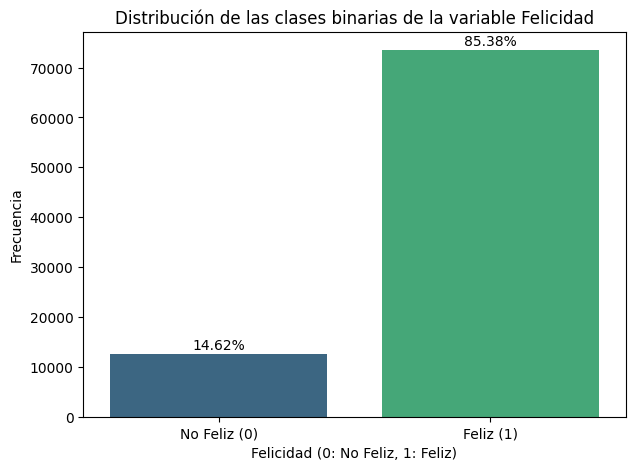

In [ ]:
# Visualización de la distribución de clases de Felicidad
plt.figure(figsize=(7, 5))
sns.countplot(x='Felicidad', data=copia_datos, palette='viridis', hue='Felicidad', legend=False)

# Calcular los porcentajes
total = len(copia_datos['Felicidad'])
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width()/2.,
                    height + 300, # Ajusta esta cantidad para la posición de la etiqueta
                    '{:1.2f}%'.format(100*height/total),
                    ha='center', va='bottom')

plt.title('Distribución de las clases binarias de la variable Felicidad')
plt.xlabel('Felicidad (0: No Feliz, 1: Feliz)')
plt.ylabel('Frecuencia')
plt.xticks([0, 1], ['No Feliz (0)', 'Feliz (1)'])
plt.show()

A primera vista se observa que el data set está desbalanceado donde el 85.38% de los encuestados están felices y 14.62% no felices. Luego se tratará este problema en el sub conjunto de datos de entrenamiento.

### Total de países encuestados

In [ ]:
num_unique_countries = copia_datos['País'].nunique()
print(f"Número total de países en el dataset: {num_unique_countries}")

Número total de países en el dataset: 57


In [ ]:
unique_countries = copia_datos['País'].unique()
print("Países únicos en el dataset:")
for country in unique_countries:
    print(f"- {country}")

Países únicos en el dataset:
- Estados Unidos
- Canadá
- México
- Guatemala
- Colombia
- Venezuela
- Ecuador
- Perú
- Brasil
- Bolivia
- Chile
- Argentina
- Uruguay
- Reino Unido
- Países Bajos
- Alemania
- República Checa
- Eslovaquia
- Serbia
- Grecia
- Chipre
- Rumanía
- Rusia
- Ucrania
- Armenia
- Nigeria
- Kenia
- Etiopía
- Zimbabué
- Túnez
- Irán
- Turquía
- Irak
- Egipto
- Líbano
- Tayikistán 
- Kirguistán
- Uzbekistán
- Kazajistán
- China
- Mongolia
- Taiwán
- Corea del Sur
- Japón
- India
- Pakistán
- Bangladesh
- Myanmar
- Maldivas
- Tailandia
- Vietnam
- Malasia
- Singapur
- Filipinas
- Indonesia
- Australia
- Nueva Zelanda


Países agrupados por región

In [ ]:
# Agrupar por 'Región' y 'País' y contar el número de individuos
regional_country_counts = copia_datos.groupby(['Región', 'País']).size().reset_index(name='Número de Encuestados')

# Calcular el total de individuos por región
regional_totals = copia_datos.groupby('Región').size().reset_index(name='Total Regional')

# Unir los resultados para mostrar en una sola tabla o de forma estructurada
print("Distribución de Encuestados por Región y País:")
for region in regional_country_counts['Región'].unique():
    print(f"\nRegión: {region}")
    region_df = regional_country_counts[regional_country_counts['Región'] == region]
    print(region_df[['País', 'Número de Encuestados']].to_string(index=False))
    total_region = regional_totals[regional_totals['Región'] == region]['Total Regional'].iloc[0]
    print(f"Total de encuestados en {region}: {total_region}")

Distribución de Encuestados por Región y País:

Región: América Latina y El Caribe
     País  Número de Encuestados
Argentina                    983
  Bolivia                   2061
   Brasil                   1745
    Chile                    982
 Colombia                   1520
  Ecuador                   1180
Guatemala                   1229
   México                   1741
     Perú                   1395
  Uruguay                    978
Venezuela                   1190
Total de encuestados en América Latina y El Caribe: 15004

Región: América del Norte
          País  Número de Encuestados
        Canadá                   4018
Estados Unidos                   2588
Total de encuestados en América del Norte: 6606

Región: Asia Central
       País  Número de Encuestados
 Kazajistán                   1211
 Kirguistán                   1199
Tayikistán                    1200
 Uzbekistán                   1229
Total de encuestados en Asia Central: 4839

Región: Asia Meridional
      Paí

In [ ]:
regional_country_counts_renamed = regional_country_counts.rename(columns={'Número de Encuestados': 'Total de Encuestados'})

print("Distribución de Encuestados por Región y País (con 'Total de Encuestados'):")

# Displaying the DataFrame, sorted for better readability
# Sort by Region and then by Total de Encuestados in descending order
display(regional_country_counts_renamed.sort_values(by=['Región', 'Total de Encuestados'], ascending=[True, False]))

Distribución de Encuestados por Región y País (con 'Total de Encuestados'):


,Región,País,Total de Encuestados
1,América Latina y El Caribe,Bolivia,2061
2,América Latina y El Caribe,Brasil,1745
7,América Latina y El Caribe,México,1741
4,América Latina y El Caribe,Colombia,1520
8,América Latina y El Caribe,Perú,1395
...,...,...,...
53,África Subsahariana,Nigeria,1233
51,África Subsahariana,Etiopía,1230
54,África Subsahariana,Zimbabué,1214
56,África del Norte,Túnez,1206


Porcentaje de personas felices e infelices por región

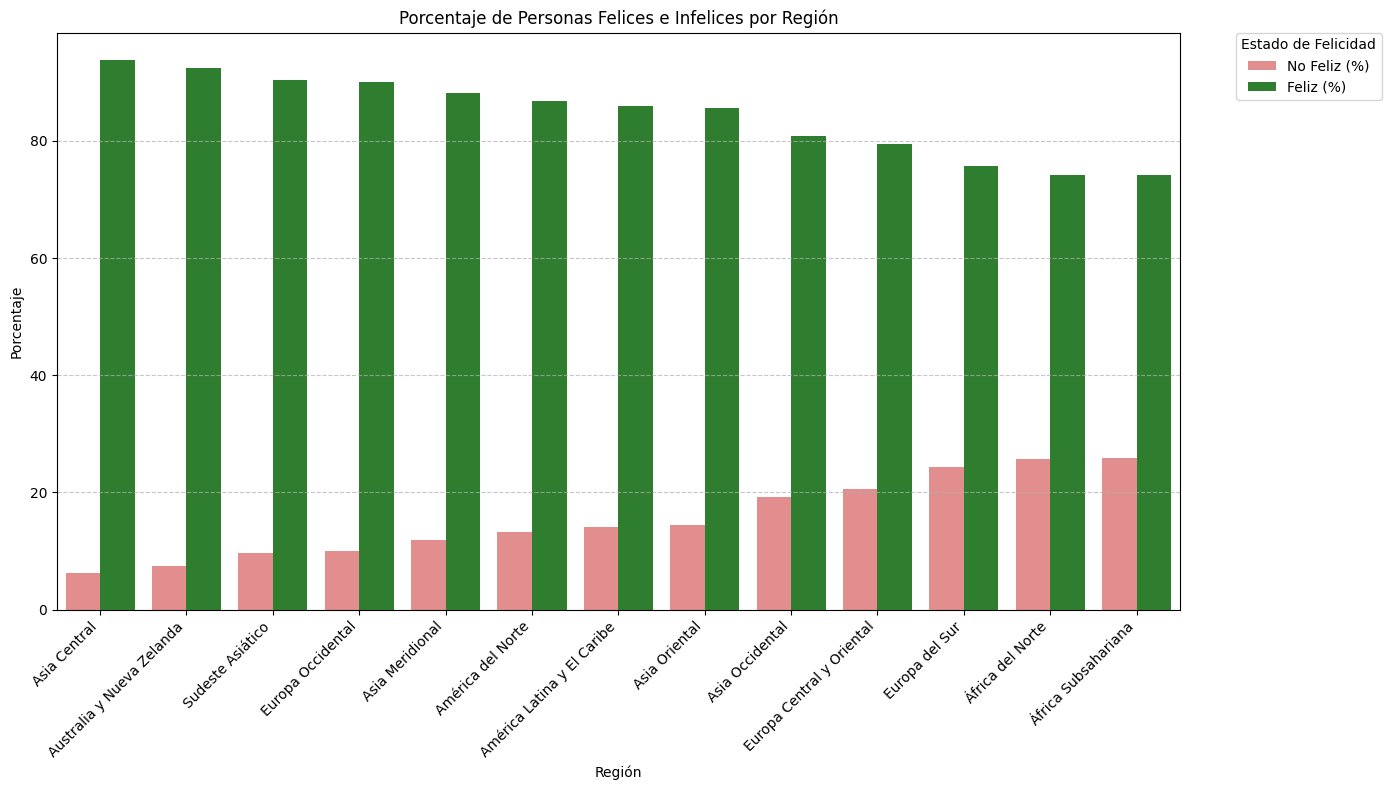

In [ ]:
# Calcular el porcentaje de personas felices e infelices por región
felicidad_por_region = copia_datos.groupby(['Región', 'Felicidad']).size().unstack(fill_value=0)

# Asegurarse de que las columnas 0 y 1 existan, incluso si no hay valores para una de ellas
if 0.0 not in felicidad_por_region.columns:
    felicidad_por_region[0.0] = 0
if 1.0 not in felicidad_por_region.columns:
    felicidad_por_region[1.0] = 0

felicidad_por_region['Total'] = felicidad_por_region[0.0] + felicidad_por_region[1.0]
felicidad_por_region['No Feliz (%)'] = (felicidad_por_region[0.0] / felicidad_por_region['Total']) * 100
felicidad_por_region['Feliz (%)'] = (felicidad_por_region[1.0] / felicidad_por_region['Total']) * 100

# Preparar los datos para el gráfico
df_plot = felicidad_por_region[['No Feliz (%)', 'Feliz (%)']].reset_index()
df_plot_melted = df_plot.melt(id_vars='Región', var_name='Estado de Felicidad', value_name='Porcentaje')

# Ordenar las regiones por el porcentaje de personas felices de forma descendente
df_plot_melted_sorted = df_plot_melted[df_plot_melted['Estado de Felicidad'] == 'Feliz (%)'].sort_values(by='Porcentaje', ascending=False)
order = df_plot_melted_sorted['Región'].tolist()

plt.figure(figsize=(14, 8))
sns.barplot(
    x='Región',
    y='Porcentaje',
    hue='Estado de Felicidad',
    data=df_plot_melted,
    palette={'Feliz (%)': 'forestgreen', 'No Feliz (%)': 'lightcoral'}, # Changed 'viridis' to 'forestgreen'
    order=order,
)

plt.title('Porcentaje de Personas Felices e Infelices por Región')
plt.xlabel('Región')
plt.ylabel('Porcentaje')
plt.legend(title='Estado de Felicidad', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

In [ ]:
print("Porcentaje de personas felices por región:")
print(felicidad_por_region[['Feliz (%)']].sort_values(by='Feliz (%)', ascending=False).to_string())

Porcentaje de personas felices por región:
Felicidad                   Feliz (%)
Región                               
Asia Central                93.738376
Australia y Nueva Zelanda   92.479603
Sudeste Asiático            90.296194
Europa Occidental           89.970741
Asia Meridional             88.146770
América del Norte           86.815017
América Latina y El Caribe  85.977073
Asia Oriental               85.623154
Asia Occidental             80.791426
Europa Central y Oriental   79.403345
Europa del Sur              75.647900
África del Norte            74.220374
África Subsahariana         74.117647


Porcentaje de personas felices por país

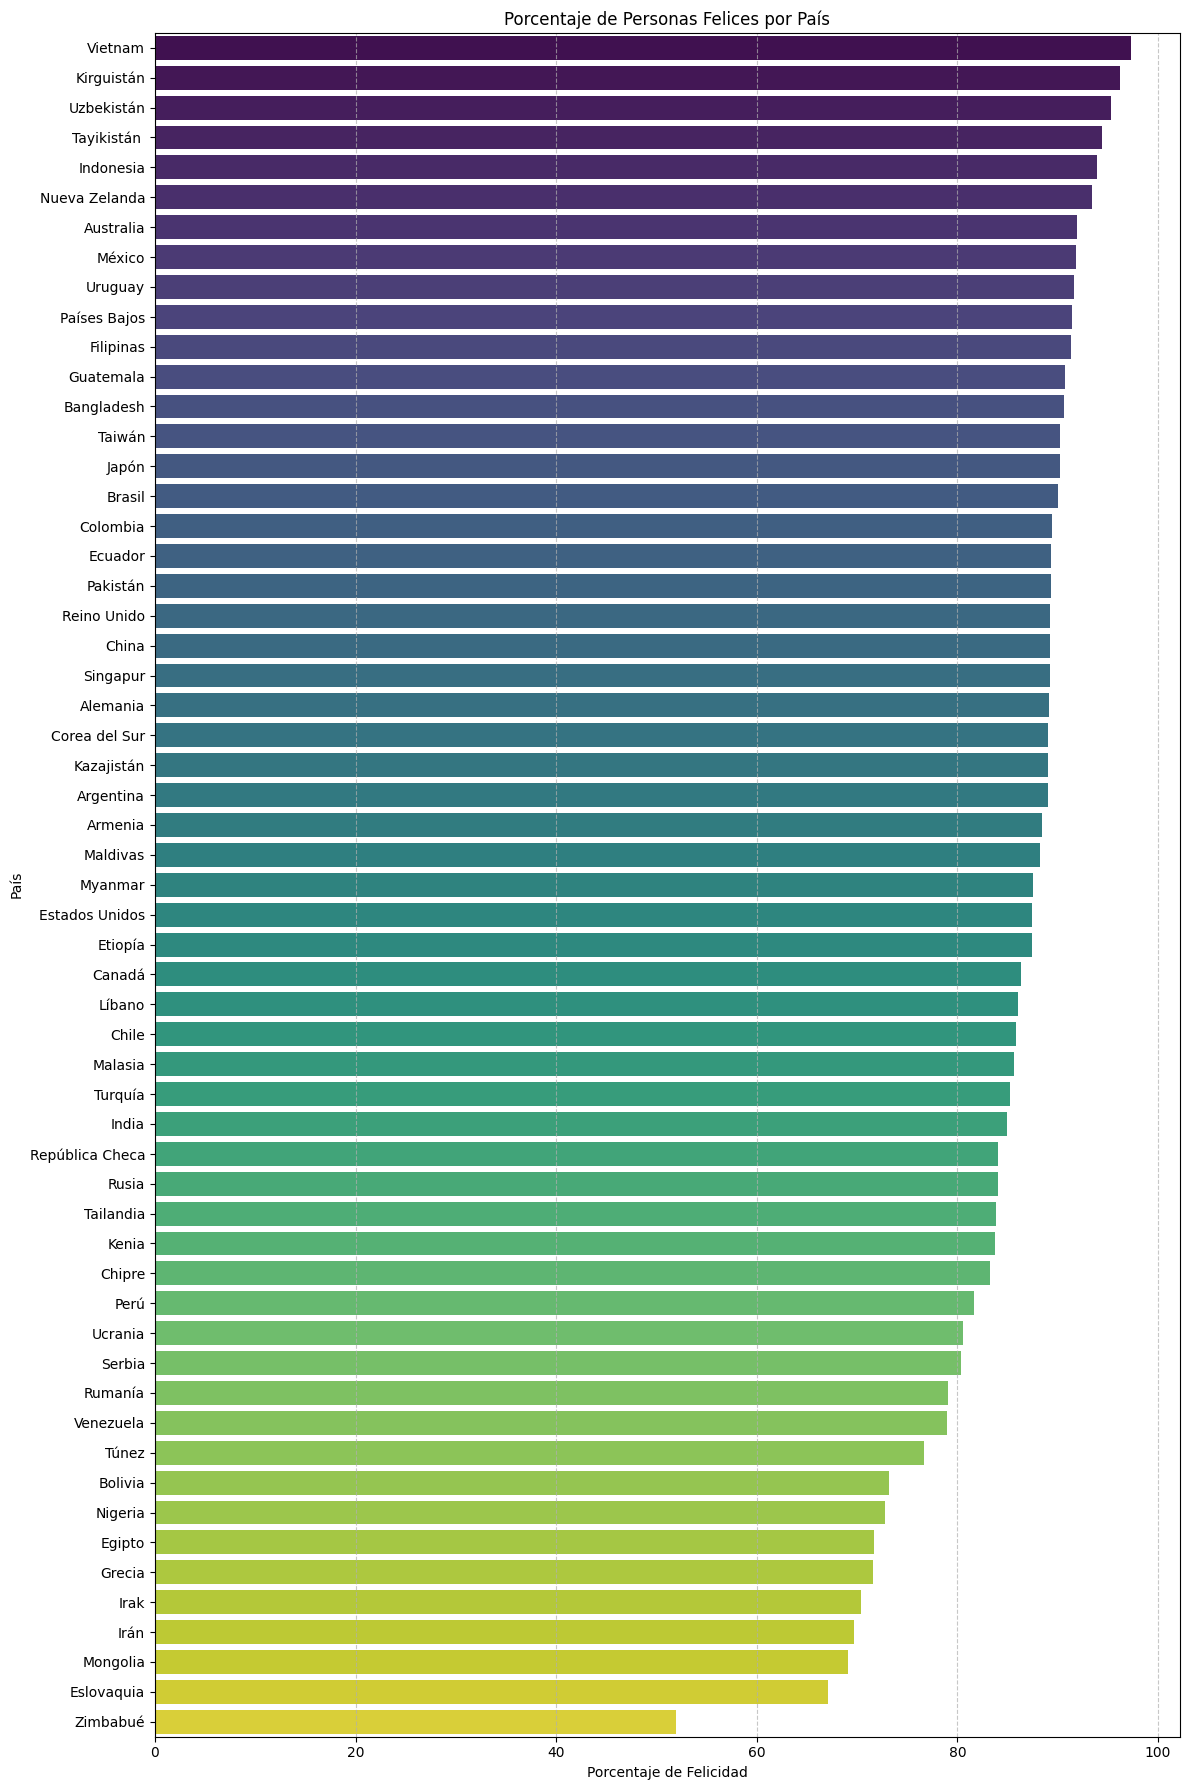

In [ ]:
# Calcular el porcentaje de personas felices por país
happiness_by_country = copia_datos.groupby('País')['Felicidad'].mean().reset_index()
happiness_by_country['Felicidad (%)'] = happiness_by_country['Felicidad'] * 100

# Ordenar los países por porcentaje de felicidad de forma descendente
happiness_by_country_sorted = happiness_by_country.sort_values(by='Felicidad (%)', ascending=False)

# Crear el gráfico de barras horizontales
plt.figure(figsize=(12, 18)) # Ajustar el tamaño para acomodar muchos países
sns.barplot(
    x='Felicidad (%)',
    y='País',
    data=happiness_by_country_sorted,
    palette='viridis',
    hue='País', # Asignar 'País' a hue
    legend=False # Ocultar la leyenda ya que el hue es el mismo que el eje y
)

plt.title('Porcentaje de Personas Felices por País')
plt.xlabel('Porcentaje de Felicidad')
plt.ylabel('País')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Ajustar para que las etiquetas no se corten
plt.show()

Ranking de países más felices

In [ ]:
# Calcular la frecuencia de personas felices por país
frecuencia_felices_por_pais = copia_datos[copia_datos['Felicidad'] == 1.0].groupby('País').size().reset_index(name='Frecuencia Felices')

# happiness_by_country_sorted ya contiene 'País' y 'Felicidad (%)' ordenados.
# Combinar con el DataFrame que ya tiene el porcentaje de felicidad ordenado
ranking_felicidad_pais = pd.merge(happiness_by_country_sorted, frecuencia_felices_por_pais, on='País', how='left')

# Crear el DataFrame con el total de encuestados por país (de regional_country_counts)
total_encuestados_por_pais = regional_country_counts.groupby('País')['Número de Encuestados'].sum().reset_index(name='Total de Encuestados')

# Unir el ranking con el total de encuestados
ranking_felicidad_pais = pd.merge(ranking_felicidad_pais, total_encuestados_por_pais, on='País', how='left')

# Añadir la columna de Ranking
# Usar 'min' para que los países con el mismo porcentaje compartan el mismo rango
ranking_felicidad_pais['Rank'] = ranking_felicidad_pais['Felicidad (%)'].rank(ascending=False, method='min').astype(int)

# Reordenar las columnas para el resultado final y ordenar por 'Rank'
final_ranking_display = ranking_felicidad_pais[['Rank', 'País', 'Total de Encuestados', 'Frecuencia Felices', 'Felicidad (%)']].sort_values(by='Rank')

# Mostrar la tabla
print("Ranking de Países por Porcentaje de Felicidad:")
print(final_ranking_display.to_string(index=False))

Ranking de Países por Porcentaje de Felicidad:
 Rank            País  Total de Encuestados  Frecuencia Felices  Felicidad (%)
    1         Vietnam                  1200                1168      97.333333
    2      Kirguistán                  1199                1154      96.246872
    3      Uzbekistán                  1229                1171      95.280716
    4     Tayikistán                   1200                1133      94.416667
    5       Indonesia                  3199                3004      93.904345
    6   Nueva Zelanda                  1014                 947      93.392505
    7       Australia                  1805                1660      91.966759
    8          México                  1741                1598      91.786330
    9         Uruguay                   978                 896      91.615542
   10    Países Bajos                  2036                1862      91.453831
   11       Filipinas                  1199                1095      91.326105
   12

### Correlación de la variable Felicidad con Satisfacción Vida

In [ ]:
from scipy.stats import pearsonr
import pandas as pd
import numpy as np

# Seleccionar las columnas de interés y eliminar NaNs
df_correlation = copia_datos[['Felicidad', 'satisfacciónvital']].dropna()

# Verificar si hay suficientes datos después de eliminar NaNs
if len(df_correlation) > 1:
    # Correlación de Pearson
    pearson_corr, pearson_p_value = pearsonr(df_correlation['Felicidad'], df_correlation['satisfacciónvital'])
    print(f"Correlación de Pearson entre Felicidad y satisfacciónvital: {pearson_corr:.4f}")
    print(f"Valor p (Pearson): {pearson_p_value:.4f}")
    if pearson_p_value < 0.05:
        print("La correlación de Pearson es estadísticamente significativa (p < 0.05).")
    else:
        print("La correlación de Pearson no es estadísticamente significativa (p >= 0.05).")
else:
    print("No hay suficientes datos para calcular la correlación después de eliminar los valores NaN.")

Correlación de Pearson entre Felicidad y satisfacciónvital: 0.3772
Valor p (Pearson): 0.0000
La correlación de Pearson es estadísticamente significativa (p < 0.05).


### Perfil del encuestado

**Sexo**

Frecuencia y porcentaje de los valores en la variable 'sexo':
      Frecuencia  Porcentaje
sexo                        
2.0        45317   52.624428
1.0        40713   47.278027
NaN           84    0.097545


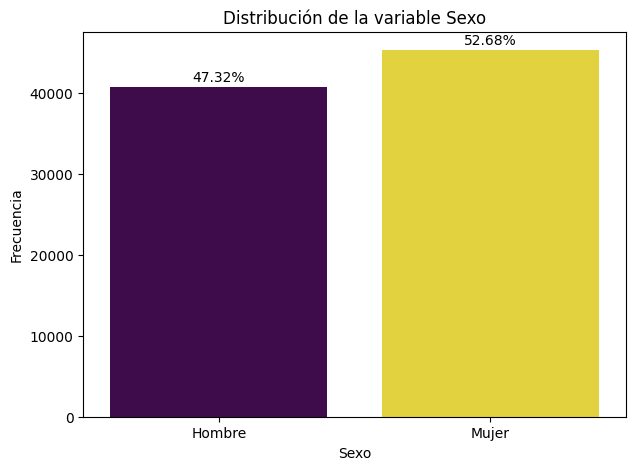

In [ ]:
print("Frecuencia y porcentaje de los valores en la variable 'sexo':")
value_counts_sexo = copia_datos['sexo'].value_counts(dropna=False)
percentage_sexo = copia_datos['sexo'].value_counts(normalize=True, dropna=False) * 100

result_df_sexo = pd.DataFrame({'Frecuencia': value_counts_sexo, 'Porcentaje': percentage_sexo})
print(result_df_sexo)

plt.figure(figsize=(7, 5))
sns.countplot(x='sexo', data=copia_datos, palette='viridis', hue='sexo', legend=False)

# Calcular los porcentajes y añadir etiquetas
total_sexo = len(copia_datos['sexo'].dropna()) # Excluir NaN para el total si se desea solo los válidos
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width()/2.,
                    height + 300, # Ajusta esta cantidad para la posición de la etiqueta
                    '{:1.2f}%'.format(100*height/total_sexo),
                    ha='center', va='bottom')

plt.title('Distribución de la variable Sexo')
plt.xlabel('Sexo')
plt.ylabel('Frecuencia')
plt.xticks([0, 1], ['Hombre', 'Mujer'])
plt.show()

**Edad**

/tmp/ipykernel_2418/1746613793.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(copia_datos['edad'].dropna(), bins=30, kde=True, palette='viridis')


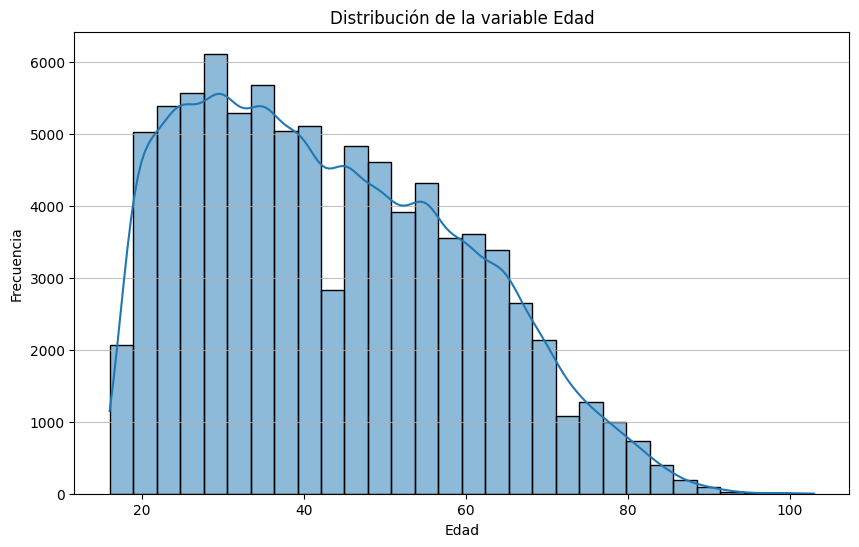

In [ ]:
# Histograma de la variable 'edad'
plt.figure(figsize=(10, 6))
sns.histplot(copia_datos['edad'].dropna(), bins=30, kde=True, palette='viridis')
plt.title('Distribución de la variable Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
print("Resumen estadístico de la variable 'edad':")
print(copia_datos['edad'].describe())

Resumen estadístico de la variable 'edad':
count    85881.000000
mean        43.144467
std         16.608462
min         16.000000
25%         29.000000
50%         41.000000
75%         55.000000
max        103.000000
Name: edad, dtype: float64


**Grupo Etario**

Frecuencia y porcentaje de los valores en la variable 'grupoetario':
                      Frecuencia  Porcentaje
grupoetario_etiqueta                        
15-24 años                 12462   14.471515
25-34 años                 18659   21.667789
35-44 años                 16947   19.679727
45-54 años                 14631   16.990269
55-64 años                 12348   14.339132
65 o más                   10834   12.580997
NaN                          233    0.270572


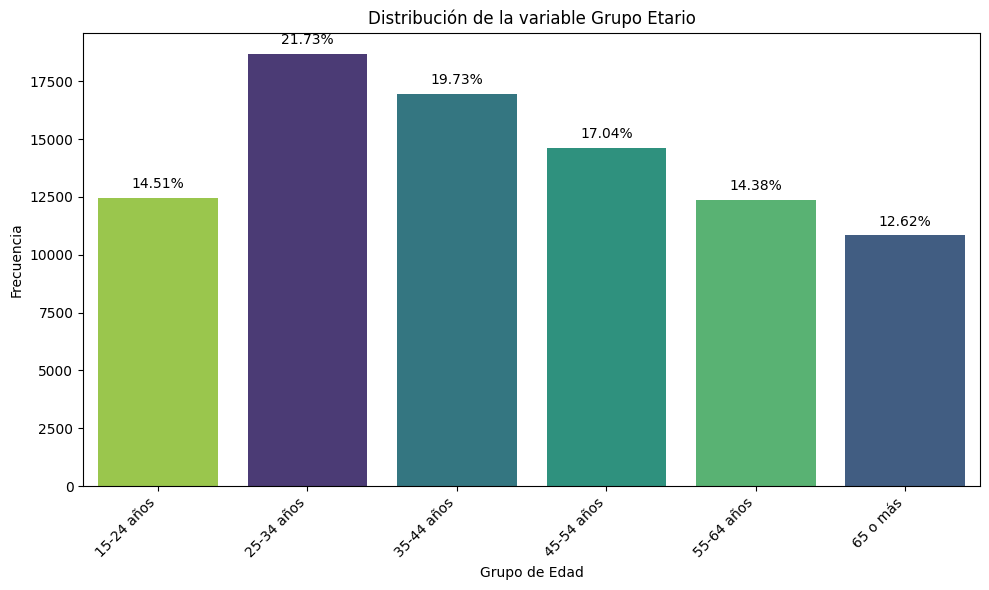

In [ ]:
# Mapeo de los valores numéricos a las etiquetas de grupo etario
grupoetario_labels = {
    1: '15-24 años',
    2: '25-34 años',
    3: '35-44 años',
    4: '45-54 años',
    5: '55-64 años',
    6: '65 o más'
}

# Crear una columna con las etiquetas para facilitar la visualización
copia_datos['grupoetario_etiqueta'] = copia_datos['grupoetario'].map(grupoetario_labels)

print("Frecuencia y porcentaje de los valores en la variable 'grupoetario':")
value_counts_grupoetario = copia_datos['grupoetario_etiqueta'].value_counts(dropna=False).sort_index()
percentage_grupoetario = copia_datos['grupoetario_etiqueta'].value_counts(normalize=True, dropna=False).sort_index() * 100

result_df_grupoetario = pd.DataFrame({'Frecuencia': value_counts_grupoetario, 'Porcentaje': percentage_grupoetario})
print(result_df_grupoetario)

plt.figure(figsize=(10, 6))
sns.countplot(x='grupoetario_etiqueta', data=copia_datos, palette='viridis', order=grupoetario_labels.values(), hue='grupoetario_etiqueta', legend=False)

# Calcular los porcentajes y añadir etiquetas
total_grupoetario = len(copia_datos['grupoetario'].dropna()) # Excluir NaN para el total si se desea solo los válidos
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width()/2.,
                    height + 300, # Ajusta esta cantidad para la posición de la etiqueta
                    '{:1.2f}%'.format(100*height/total_grupoetario),
                    ha='center', va='bottom')

plt.title('Distribución de la variable Grupo Etario')
plt.xlabel('Grupo de Edad')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

**Tipo de Hogar: Urbano o Rural**

Frecuencia y porcentaje del tipo de hogar de los encuestados):
            Frecuencia  Porcentaje
tipo_hogar                        
Urbano           56721   65.867339
Rural            29361   34.095501
NaN                 32    0.037160


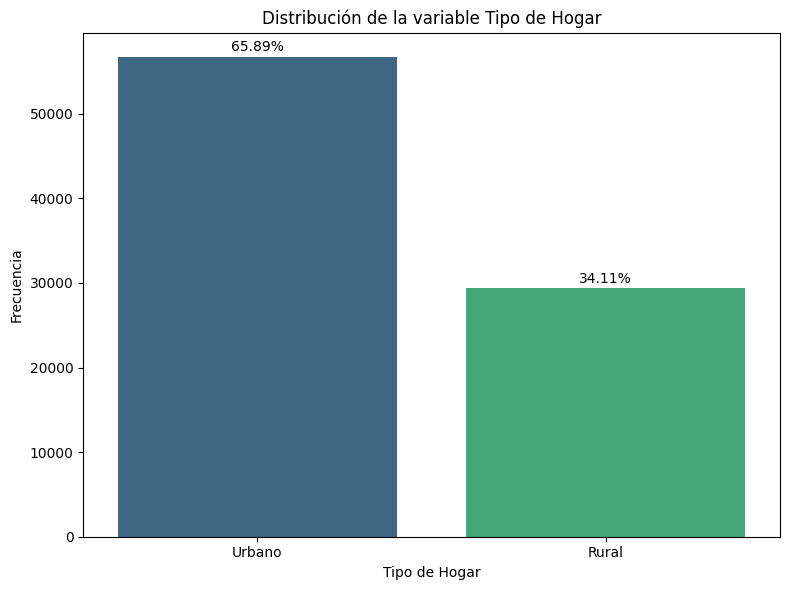

In [ ]:
# Mapeo de los valores numéricos a las etiquetas de tipo de área (Urbano/Rural)
x050c_labels = {
    1.0: 'Urbano',
    2.0: 'Rural'
}

# Crear una columna con las etiquetas para facilitar la visualización
copia_datos['tipo_hogar'] = copia_datos['tipohogar'].map(x050c_labels)

print("Frecuencia y porcentaje del tipo de hogar de los encuestados):")
value_counts_tipo_area = copia_datos['tipo_hogar'].value_counts(dropna=False)
percentage_tipo_area = copia_datos['tipo_hogar'].value_counts(normalize=True, dropna=False) * 100

result_df_tipo_area = pd.DataFrame({'Frecuencia': value_counts_tipo_area, 'Porcentaje': percentage_tipo_area})
print(result_df_tipo_area)

plt.figure(figsize=(8, 6))
sns.countplot(x='tipo_hogar', data=copia_datos, palette='viridis', hue='tipo_hogar', legend=False, order=x050c_labels.values())

# Calcular los porcentajes y añadir etiquetas
total_tipo_area = len(copia_datos['tipo_hogar'].dropna()) # Excluir NaN para el total si se desea solo los válidos
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width()/2.,
                    height + 300, # Ajusta esta cantidad para la posición de la etiqueta
                    '{:1.2f}%'.format(100*height/total_tipo_area),
                    ha='center', va='bottom')

plt.title('Distribución de la variable Tipo de Hogar')
plt.xlabel('Tipo de Hogar')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

**Nivel de Educación**

Frecuencia y porcentaje de los valores en la variable 'educ':
                          Frecuencia  Porcentaje
educ_etiqueta                                   
Doctorado                       1069    1.241378
Formación Profesional           8190    9.510649
Licenciatura/Grado             14378   16.696472
Maestría                        5707    6.627262
Preescolar/Sin Educación        4306    5.000348
Primaria                       10175   11.815733
Secundaria Básica              12702   14.750215
Secundaria Superior            21859   25.383794
Técnico Superior                6800    7.896509
NaN                              928    1.077641


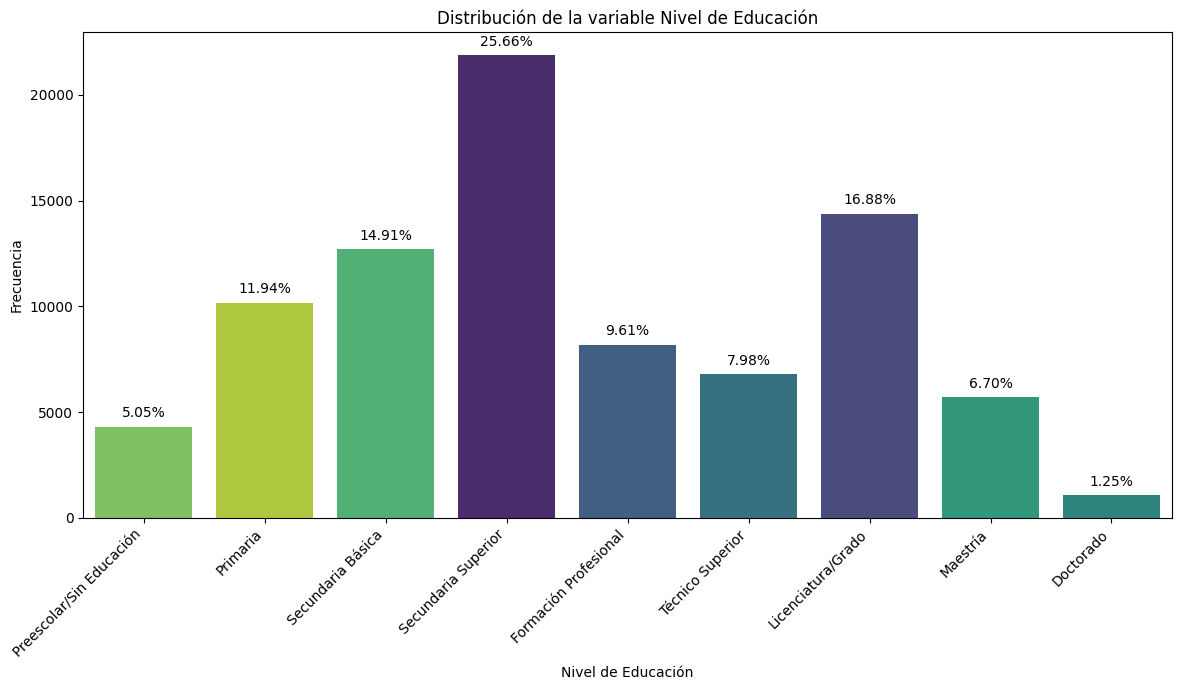

In [ ]:
# Mapeo de los valores numéricos a las etiquetas de nivel educativo
educ_labels = {
    0.0: 'Preescolar/Sin Educación',
    1.0: 'Primaria',
    2.0: 'Secundaria Básica',
    3.0: 'Secundaria Superior',
    4.0: 'Formación Profesional',
    5.0: 'Técnico Superior',
    6.0: 'Licenciatura/Grado',
    7.0: 'Maestría',
    8.0: 'Doctorado'
}

# Crear una columna con las etiquetas para facilitar la visualización
copia_datos['educ_etiqueta'] = copia_datos['educ'].map(educ_labels)

print("Frecuencia y porcentaje de los valores en la variable 'educ':")
value_counts_educ = copia_datos['educ_etiqueta'].value_counts(dropna=False).sort_index()
percentage_educ = copia_datos['educ_etiqueta'].value_counts(normalize=True, dropna=False).sort_index() * 100

result_df_educ = pd.DataFrame({'Frecuencia': value_counts_educ, 'Porcentaje': percentage_educ})
print(result_df_educ)

plt.figure(figsize=(12, 7))
sns.countplot(x='educ_etiqueta', data=copia_datos, palette='viridis', hue='educ_etiqueta', legend=False,
              order=[educ_labels[key] for key in sorted(educ_labels.keys())])

# Calcular los porcentajes y añadir etiquetas
total_educ = len(copia_datos['educ'].dropna()) # Excluir NaN para el total si se desea solo los válidos
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width()/2.,
                    height + 300, # Ajusta esta cantidad para la posición de la etiqueta
                    '{:1.2f}%'.format(100*height/total_educ),
                    ha='center', va='bottom')

plt.title('Distribución de la variable Nivel de Educación')
plt.xlabel('Nivel de Educación')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

**Estatus Laboral**

Frecuencia y porcentaje de los valores en la variable 'estatuslaboral':
                                     Frecuencia  Porcentaje
estatuslaboral_etiqueta                                    
A tiempo completo                         30272   35.153401
Trabajador/a por cuenta propia            13036   15.138073
Ama de casa / Tareas domésticas           11354   13.184848
Retirado/a                                10609   12.319716
A tiempo parcial                           7271    8.443459
Desempleado/a (buscando trabajo)           6587    7.649163
Estudiante                                 4938    5.734259
NaN                                        1080    1.254151
Desempleado/a (no buscando trabajo)         967    1.122930


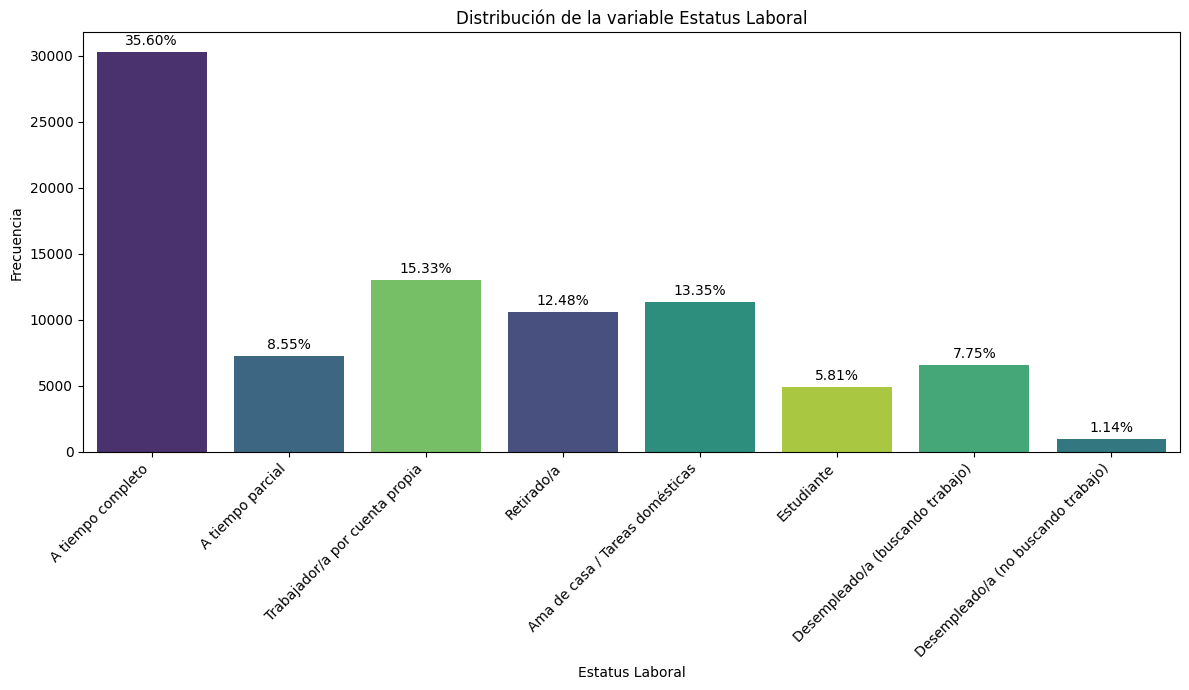

In [ ]:
# Mapeo de los valores numéricos a las etiquetas de estatus laboral (basado en WVS Codebook)
estatuslaboral_labels = {
    1.0: 'A tiempo completo',
    2.0: 'A tiempo parcial',
    3.0: 'Trabajador/a por cuenta propia',
    4.0: 'Retirado/a',
    5.0: 'Ama de casa / Tareas domésticas',
    6.0: 'Estudiante',
    7.0: 'Desempleado/a (buscando trabajo)',
    8.0: 'Desempleado/a (no buscando trabajo)',
}

# Crear una columna con las etiquetas para facilitar la visualización
copia_datos['estatuslaboral_etiqueta'] = copia_datos['estatuslaboral'].map(estatuslaboral_labels)

print("Frecuencia y porcentaje de los valores en la variable 'estatuslaboral':")
value_counts_estatuslaboral = copia_datos['estatuslaboral_etiqueta'].value_counts(dropna=False)
percentage_estatuslaboral = copia_datos['estatuslaboral_etiqueta'].value_counts(normalize=True, dropna=False) * 100

result_df_estatuslaboral = pd.DataFrame({'Frecuencia': value_counts_estatuslaboral, 'Porcentaje': percentage_estatuslaboral})
print(result_df_estatuslaboral)

plt.figure(figsize=(12, 7))
sns.countplot(x='estatuslaboral_etiqueta', data=copia_datos, palette='viridis', hue='estatuslaboral_etiqueta', legend=False,
              order=[estatuslaboral_labels[key] for key in sorted(estatuslaboral_labels.keys())])

# Calcular los porcentajes y añadir etiquetas
total_estatuslaboral = len(copia_datos['estatuslaboral'].dropna()) # Excluir NaN para el total si se desea solo los válidos
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width()/2.,
                    height + 300, # Ajusta esta cantidad para la posición de la etiqueta
                    '{:1.2f}%'.format(100*height/total_estatuslaboral),
                    ha='center', va='bottom')

plt.title('Distribución de la variable Estatus Laboral')
plt.xlabel('Estatus Laboral')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

**Nivel de Ingresos**

Frecuencia y porcentaje de los valores en la variable 'nivelingresos':
                        Frecuencia  Porcentaje
nivelingresos_etiqueta                        
Alto                          3518    4.085282
Bajo                         11456   13.303296
Medio                        32514   37.756927
Medio-Alto                   15012   17.432705
Medio-Bajo                   21087   24.487308
NaN                           2527    2.934482


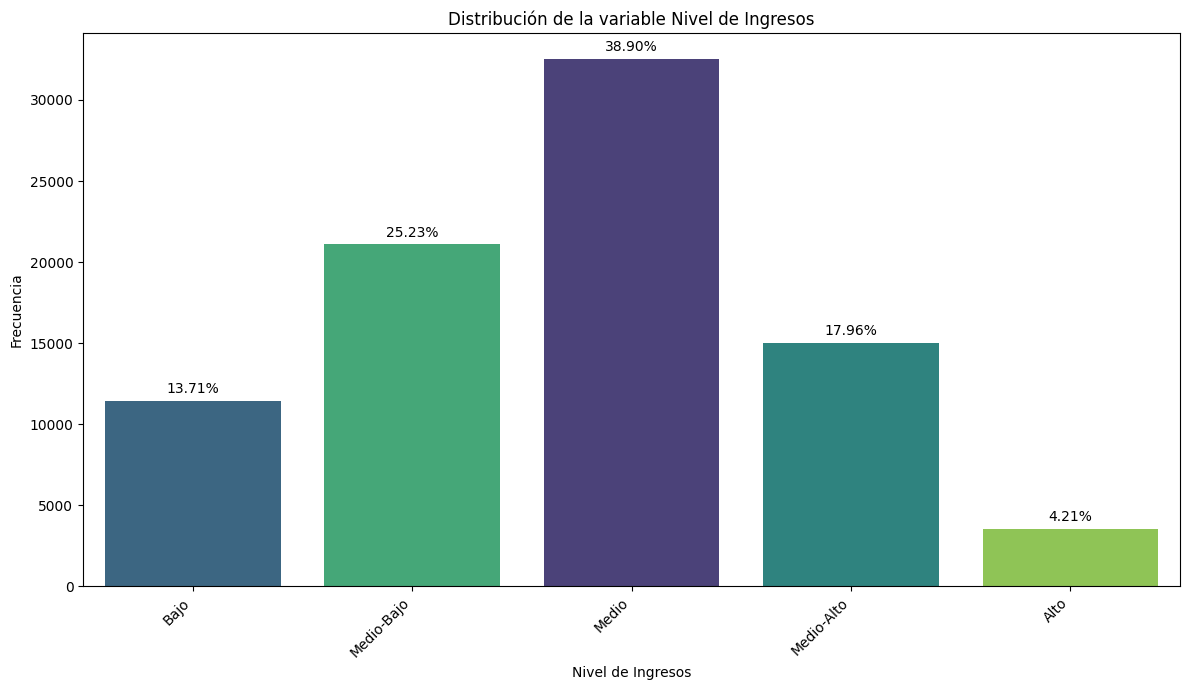

In [ ]:
# Mapeo de los valores numéricos a las etiquetas de nivel de ingresos
nivelingresos_labels = {
    1.0: 'Bajo', 2.0: 'Bajo',
    3.0: 'Medio-Bajo', 4.0: 'Medio-Bajo',
    5.0: 'Medio', 6.0: 'Medio',
    7.0: 'Medio-Alto', 8.0: 'Medio-Alto',
    9.0: 'Alto', 10.0: 'Alto'
}

# Crear una copia para evitar PerformanceWarning por fragmentación del DataFrame
copia_datos_temp = copia_datos.copy()

# Crear una columna con las etiquetas para facilitar la visualización
copia_datos_temp['nivelingresos_etiqueta'] = copia_datos_temp['nivelingresos'].map(nivelingresos_labels)

print("Frecuencia y porcentaje de los valores en la variable 'nivelingresos':")
# Usar la nueva columna con etiquetas para los cálculos y la visualización
value_counts_nivelingresos = copia_datos_temp['nivelingresos_etiqueta'].value_counts(dropna=False).sort_index()
percentage_nivelingresos = copia_datos_temp['nivelingresos_etiqueta'].value_counts(normalize=True, dropna=False).sort_index() * 100

result_df_nivelingresos = pd.DataFrame({'Frecuencia': value_counts_nivelingresos, 'Porcentaje': percentage_nivelingresos})
print(result_df_nivelingresos)

plt.figure(figsize=(12, 7))
sns.countplot(x='nivelingresos_etiqueta', data=copia_datos_temp, palette='viridis', hue='nivelingresos_etiqueta', legend=False,
              order=[label for key, label in sorted(nivelingresos_labels.items(), key=lambda item: item[0]) if key in copia_datos_temp['nivelingresos'].unique()])

# Calcular los porcentajes y añadir etiquetas
total_nivelingresos = len(copia_datos_temp['nivelingresos_etiqueta'].dropna()) # Excluir NaN para el total si se desea solo los válidos
for p in plt.gca().patches:
    height = p.get_height()
    if total_nivelingresos > 0: # Evitar división por cero si no hay datos válidos
        plt.gca().text(p.get_x() + p.get_width()/2.,
                        height + 300, # Ajusta esta cantidad para la posición de la etiqueta
                        '{:1.2f}%'.format(100*height/total_nivelingresos),
                        ha='center', va='bottom')

plt.title('Distribución de la variable Nivel de Ingresos')
plt.xlabel('Nivel de Ingresos')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Asignar la columna de vuelta al DataFrame original si es necesario, o usar copia_datos_temp para el resto del análisis
copia_datos['nivelingresos_etiqueta'] = copia_datos_temp['nivelingresos_etiqueta']

**Clase Social (respuesta subjetiva)**

Frecuencia y porcentaje de los valores en la variable 'clasesocial':
                      Frecuencia  Porcentaje
clasesocial_etiqueta                        
Clase Alta                  1674    1.943935
Clase Baja                  9348   10.855378
Clase Media-Alta           17452   20.266159
Clase Media-Baja           30992   35.989502
Clase Trabajadora          21809   25.325731
NaN                         4839    5.619295


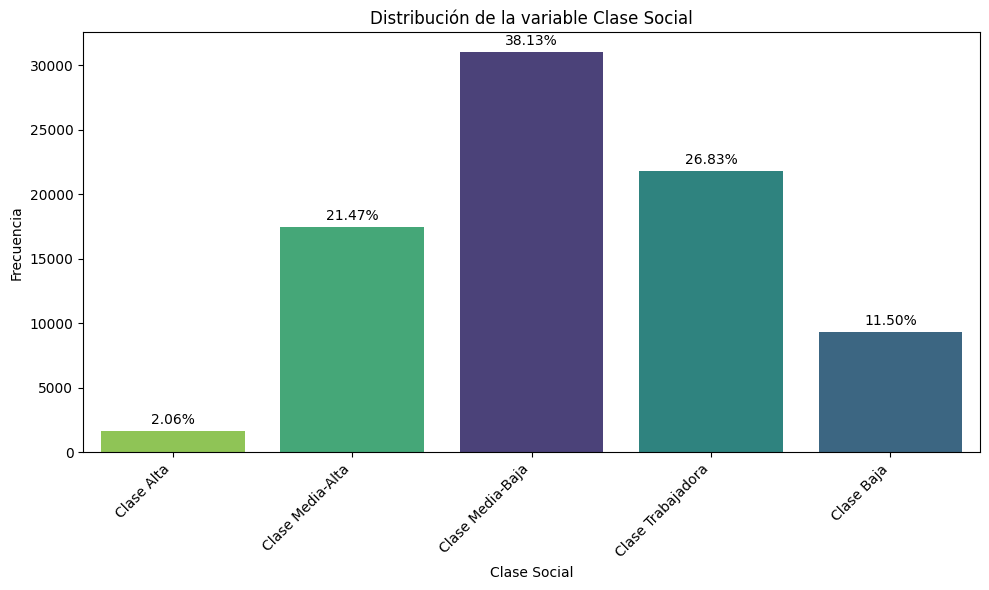

In [ ]:
# Mapeo de los valores numéricos a las etiquetas de clase social
clasesocial_labels = {
    1.0: 'Clase Alta',
    2.0: 'Clase Media-Alta',
    3.0: 'Clase Media-Baja',
    4.0: 'Clase Trabajadora',
    5.0: 'Clase Baja'
}

# Crear una copia para evitar PerformanceWarning por fragmentación del DataFrame
copia_datos_temp = copia_datos.copy()

# Crear una columna con las etiquetas para facilitar la visualización
copia_datos_temp['clasesocial_etiqueta'] = copia_datos_temp['clasesocial'].map(clasesocial_labels)

print("Frecuencia y porcentaje de los valores en la variable 'clasesocial':")
value_counts_clasesocial = copia_datos_temp['clasesocial_etiqueta'].value_counts(dropna=False).sort_index()
percentage_clasesocial = copia_datos_temp['clasesocial_etiqueta'].value_counts(normalize=True, dropna=False).sort_index() * 100

result_df_clasesocial = pd.DataFrame({'Frecuencia': value_counts_clasesocial, 'Porcentaje': percentage_clasesocial})
print(result_df_clasesocial)

plt.figure(figsize=(10, 6))
sns.countplot(x='clasesocial_etiqueta', data=copia_datos_temp, palette='viridis', hue='clasesocial_etiqueta', legend=False,
              order=[clasesocial_labels[key] for key in sorted(clasesocial_labels.keys())])

# Calcular los porcentajes y añadir etiquetas
total_clasesocial = len(copia_datos_temp['clasesocial'].dropna()) # Excluir NaN para el total si se desea solo los válidos
for p in plt.gca().patches:
    height = p.get_height()
    if total_clasesocial > 0: # Evitar división por cero si no hay datos válidos
        plt.gca().text(p.get_x() + p.get_width()/2.,
                        height + 300, # Ajusta esta cantidad para la posición de la etiqueta
                        '{:1.2f}%'.format(100*height/total_clasesocial),
                        ha='center', va='bottom')

plt.title('Distribución de la variable Clase Social')
plt.xlabel('Clase Social')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

# Asignar la columna de vuelta al DataFrame original si es necesario, o usar copia_datos_temp para el resto del análisis
copia_datos['clasesocial_etiqueta'] = copia_datos_temp['clasesocial_etiqueta']

Frecuencia y porcentaje de los valores en la variable 'clasesocial' (ordenado):
                      Frecuencia  Porcentaje
clasesocial_etiqueta                        
Clase Baja                  9348   10.855378
Clase Trabajadora          21809   25.325731
Clase Media-Baja           30992   35.989502
Clase Media-Alta           17452   20.266159
Clase Alta                  1674    1.943935
NaN                         4839    5.619295


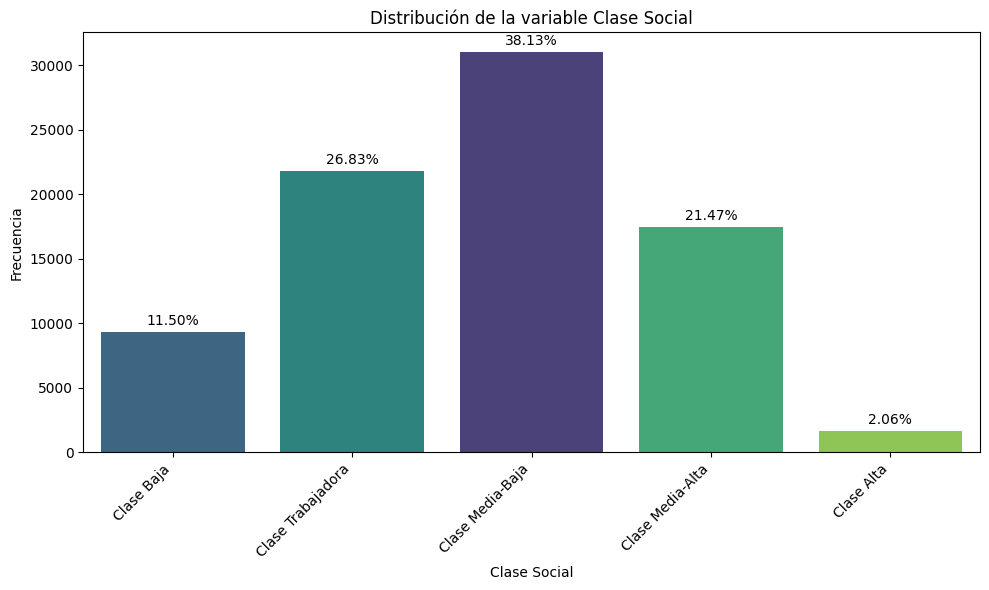

In [ ]:
# Mapeo de los valores numéricos a las etiquetas de clase social
clasesocial_labels = {
    1.0: 'Clase Alta',
    2.0: 'Clase Media-Alta',
    3.0: 'Clase Media-Baja',
    4.0: 'Clase Trabajadora',
    5.0: 'Clase Baja'
}

# 'clasesocial_etiqueta' ya debería existir en 'copia_datos' de la celda anterior.
# Si esta celda se ejecuta de forma independiente y la columna no existe, se puede descomentar la siguiente línea:
# copia_datos['clasesocial_etiqueta'] = copia_datos['clasesocial'].map(clasesocial_labels)

# Define el orden personalizado como lo solicitó el usuario
custom_order = ['Clase Baja', 'Clase Trabajadora', 'Clase Media-Baja', 'Clase Media-Alta', 'Clase Alta']

print("Frecuencia y porcentaje de los valores en la variable 'clasesocial' (ordenado):")
value_counts_clasesocial = copia_datos['clasesocial_etiqueta'].value_counts(dropna=False)
percentage_clasesocial = copia_datos['clasesocial_etiqueta'].value_counts(normalize=True, dropna=False) * 100

# Crea el DataFrame y reindexa para aplicar el orden personalizado
result_df_clasesocial = pd.DataFrame({'Frecuencia': value_counts_clasesocial, 'Porcentaje': percentage_clasesocial})

# Maneja los NaN en el índice para la impresión
if np.nan in result_df_clasesocial.index:
    ordered_index = custom_order + [np.nan]
else:
    ordered_index = custom_order

result_df_clasesocial = result_df_clasesocial.reindex(ordered_index).dropna(how='all')

print(result_df_clasesocial)

plt.figure(figsize=(10, 6))
sns.countplot(x='clasesocial_etiqueta', data=copia_datos, palette='viridis', hue='clasesocial_etiqueta', legend=False,
              order=custom_order) # Usa el orden personalizado aquí

# Calcular los porcentajes y añadir etiquetas
total_clasesocial = len(copia_datos['clasesocial_etiqueta'].dropna()) # Excluir NaN para el total si se desea solo los válidos
for p in plt.gca().patches:
    height = p.get_height()
    if total_clasesocial > 0: # Evitar división por cero si no hay datos válidos
        plt.gca().text(p.get_x() + p.get_width()/2.,
                        height + 300, # Ajusta esta cantidad para la posición de la etiqueta
                        '{:1.2f}%'.format(100*height/total_clasesocial),
                        ha='center', va='bottom')

plt.title('Distribución de la variable Clase Social')
plt.xlabel('Clase Social')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()


### Análisis Visual con Variables Agregadas


**Felicidad versus PIB per cápita**

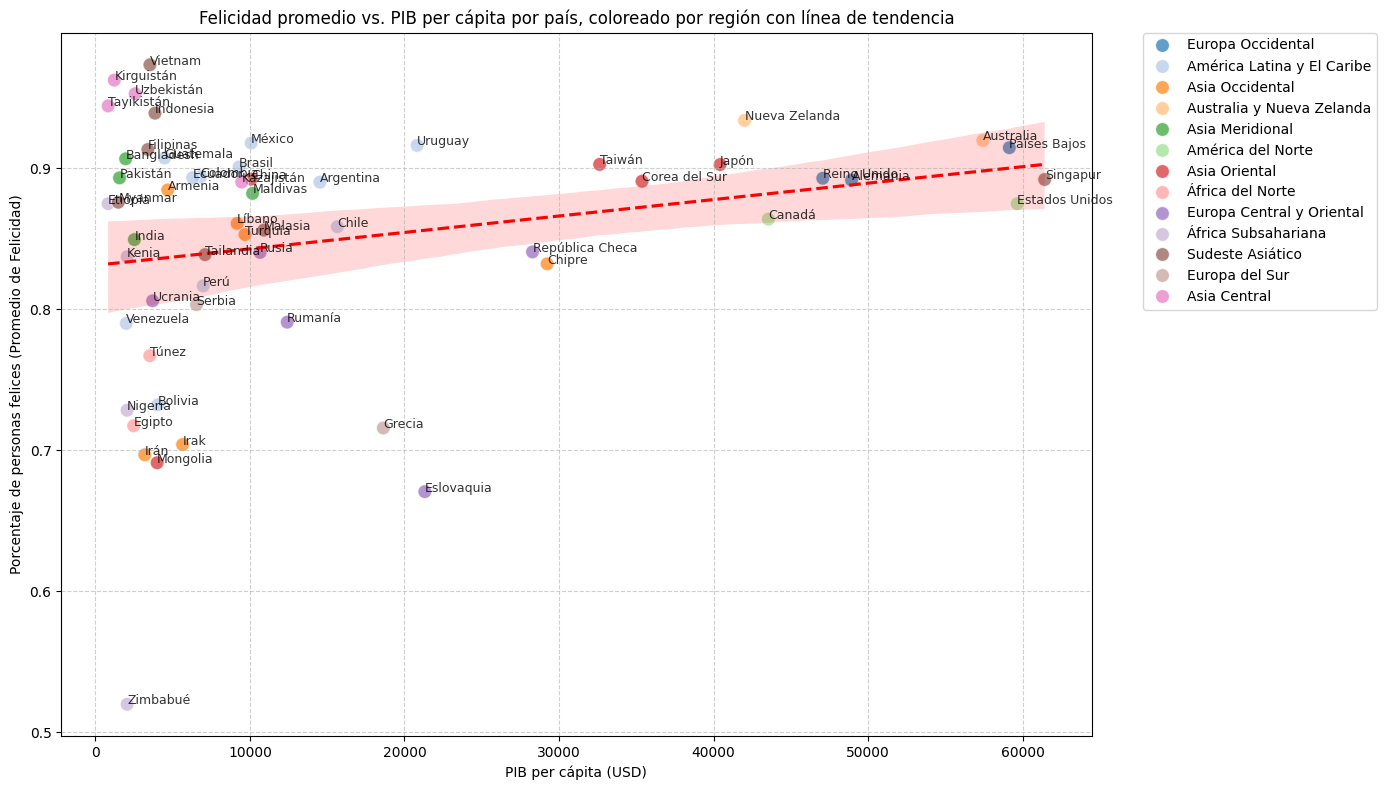

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular el promedio de 'Felicidad' y el PIB/capita por país y región
happiness_by_country = copia_datos.groupby(['País', 'Región'])[['Felicidad', 'PIB/capita']].mean().reset_index()

# Crear el gráfico de dispersión
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=happiness_by_country,
    x='PIB/capita',
    y='Felicidad',
    hue='Región',
    s=100,  # Tamaño de los puntos
    alpha=0.7, # Transparencia de los puntos
    palette='tab20' # Paleta de colores para las regiones
)

# Añadir una línea de tendencia general
sns.regplot(
    data=happiness_by_country,
    x='PIB/capita',
    y='Felicidad',
    scatter=False, # No mostrar los puntos individuales de nuevo
    color='red',   # Color de la línea de tendencia
    line_kws={'linestyle':'--'},
    ci=95 # Intervalo de confianza al 95%
)

# Añadir etiquetas de texto para cada país
for i, row in happiness_by_country.iterrows():
    plt.text(row['PIB/capita'], row['Felicidad'], row['País'], fontsize=9, alpha=0.8)

plt.title('Felicidad promedio vs. PIB per cápita por país, coloreado por región con línea de tendencia')
plt.xlabel('PIB per cápita (USD)')
plt.ylabel('Porcentaje de personas felices (Promedio de Felicidad)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

A mayor PIB per cápita mayor es la proporción de personas felices en un país. Dos cosas llaman la atención:

*   El bajo nivel de felicidad reportado por los ciudadanos de Zimbabué, exactamente un 52%, un país de la África Subsahariana donde en el 2020 (año de pandemia COVID-19 cuando se realizó la encuesta) la pobreza extrema (personas viviendo con menos de 3 dólares al día) afectaba el 49% de la población, según datos del Banco Mundial.
*   Hay un cluster importante de países que a pesar de tener menor PIB per cápita reportaron altos niveles de felicidad, principalmente los del Sudeste Asiático, Asia Meridional, Asia Central y algunos de América Latina y el Caribe.



In [ ]:
zimbabwe_happiness = happiness_by_country[happiness_by_country['País'] == 'Zimbabué']['Felicidad'].iloc[0]
percentage_zimbabwe_happiness = zimbabwe_happiness * 100

print(f"El porcentaje de personas felices en Zimbabue es: {percentage_zimbabwe_happiness:.2f}%")

El porcentaje de personas felices en Zimbabue es: 51.98%


Procedemos a comprobar la correlación Felicidad y PIB per cápita calculando los coeficientes de Pearson y Spearman:

In [ ]:
# Seleccionar las columnas de interés
df_correlation = copia_datos[['Felicidad', 'PIB/capita']].dropna()

# Verificar si hay suficientes datos después de eliminar NaNs
if len(df_correlation) > 1:
    # Correlación de Pearson
    pearson_corr, pearson_p_value = pearsonr(df_correlation['Felicidad'], df_correlation['PIB/capita'])
    print(f"Correlación de Pearson entre Felicidad y PIB/capita: {pearson_corr:.4f}")
    print(f"Valor p (Pearson): {pearson_p_value:.4f}")
    if pearson_p_value < 0.05:
        print("La correlación de Pearson es estadísticamente significativa (p < 0.05).")
    else:
        print("La correlación de Pearson no es estadísticamente significativa (p >= 0.05).")

    print("\n" + "-"*50 + "\n")

    # Correlación de Spearman
    spearman_corr, spearman_p_value = spearmanr(df_correlation['Felicidad'], df_correlation['PIB/capita'])
    print(f"Correlación de Spearman entre Felicidad y PIB/capita: {spearman_corr:.4f}")
    print(f"Valor p (Spearman): {spearman_p_value:.4f}")
    if spearman_p_value < 0.05:
        print("La correlación de Spearman es estadísticamente significativa (p < 0.05).")
    else:
        print("La correlación de Spearman no es estadísticamente significativa (p >= 0.05).")
else:
    print("No hay suficientes datos para calcular la correlación después de eliminar los valores NaN.")

Correlación de Pearson entre Felicidad y PIB/capita: 0.0566
Valor p (Pearson): 0.0000
La correlación de Pearson es estadísticamente significativa (p < 0.05).

--------------------------------------------------

Correlación de Spearman entre Felicidad y PIB/capita: 0.0465
Valor p (Spearman): 0.0000
La correlación de Spearman es estadísticamente significativa (p < 0.05).


Los coeficientes de Pearson y Spearman revelan que la correlación entre felicidad y PIB per cápita es casi nula por debajo de 0.10.

**Felicidad versus Coeficiente de Gini**

El coeficiente de Gini es un índice de desigualdad donde 1 significa perfecta desigualdad y 0 perfecta igualdad.

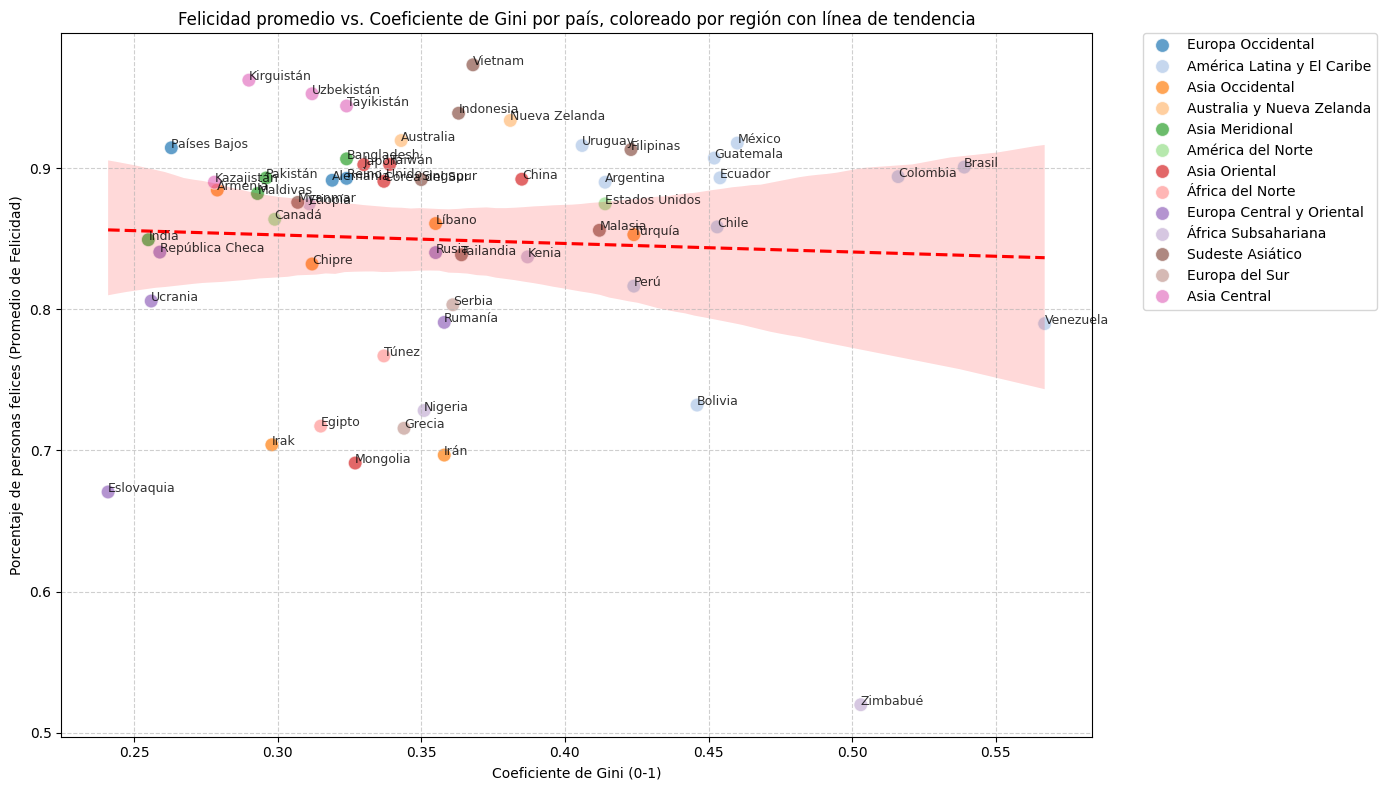

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular el promedio de 'Felicidad' y el Coeficiente de Gini por país y región
happiness_gini_by_country = copia_datos.groupby(['País', 'Región'])[['Felicidad', 'Gini']].mean().reset_index()

# Rescalar la variable Gini para que esté en un rango de 0 a 1
happiness_gini_by_country['Gini'] = happiness_gini_by_country['Gini'] / 100

# Crear el gráfico de dispersión
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=happiness_gini_by_country,
    x='Gini',
    y='Felicidad',
    hue='Región',
    s=100,
    alpha=0.7,
    palette='tab20'
)

# Añadir una línea de tendencia general
sns.regplot(
    data=happiness_gini_by_country,
    x='Gini',
    y='Felicidad',
    scatter=False,
    color='red',
    line_kws={'linestyle':'--'},
    ci=95
)

# Añadir etiquetas de texto para cada país
for i, row in happiness_gini_by_country.iterrows():
    plt.text(row['Gini'], row['Felicidad'], row['País'], fontsize=9, alpha=0.8)

plt.title('Felicidad promedio vs. Coeficiente de Gini por país, coloreado por región con línea de tendencia')
plt.xlabel('Coeficiente de Gini (0-1)')
plt.ylabel('Porcentaje de personas felices (Promedio de Felicidad)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

Aunque la pendiente de la línea de tendencia tiene una leve inclinación hacia abajo, esto puede significar que la correlación es baja entre las dos variables. No obstante, a mayor desigualdad de ingresos en un país menor es la proporción de personas felices. Países latinoamericanos como Brasil y Colombia mantienen altos niveles de felicidad (alrededor del 90%), a pesar de observarse una gran desigualdad de ingresos.

Procedemos a comprobar la correlación Felicidad y el Índice de Gini calculando los coeficientes de Pearson y Spearman:

In [ ]:
# Seleccionar las columnas de interés
df_correlation = copia_datos[['Felicidad', 'Gini']].dropna()

# Verificar si hay suficientes datos después de eliminar NaNs
if len(df_correlation) > 1:
    # Correlación de Pearson
    pearson_corr, pearson_p_value = pearsonr(df_correlation['Felicidad'], df_correlation['Gini'])
    print(f"Correlación de Pearson entre Felicidad y Coeficiente de Gini: {pearson_corr:.4f}")
    print(f"Valor p (Pearson): {pearson_p_value:.4f}")
    if pearson_p_value < 0.05:
        print("La correlación de Pearson es estadísticamente significativa (p < 0.05).")
    else:
        print("La correlación de Pearson no es estadísticamente significativa (p >= 0.05).")

    print("\n" + "-"*50 + "\n")

    # Correlación de Spearman
    spearman_corr, spearman_p_value = spearmanr(df_correlation['Felicidad'], df_correlation['Gini'])
    print(f"Correlación de Spearman entre Felicidad y Coeficiente de Gini: {spearman_corr:.4f}")
    print(f"Valor p (Spearman): {spearman_p_value:.4f}")
    if spearman_p_value < 0.05:
        print("La correlación de Spearman es estadísticamente significativa (p < 0.05).")
    else:
        print("La correlación de Spearman no es estadísticamente significativa (p >= 0.05).")
else:
    print("No hay suficientes datos para calcular la correlación después de eliminar los valores NaN.")

Correlación de Pearson entre Felicidad y Coeficiente de Gini: -0.0135
Valor p (Pearson): 0.0001
La correlación de Pearson es estadísticamente significativa (p < 0.05).

--------------------------------------------------

Correlación de Spearman entre Felicidad y Coeficiente de Gini: -0.0071
Valor p (Spearman): 0.0364
La correlación de Spearman es estadísticamente significativa (p < 0.05).


Los coeficientes de Pearson y Spearman revelan que la correlación entre felicidad y el índice de Gini es es muy débil o casi nula.

**Felicidad versus Tasa de Desempleo**

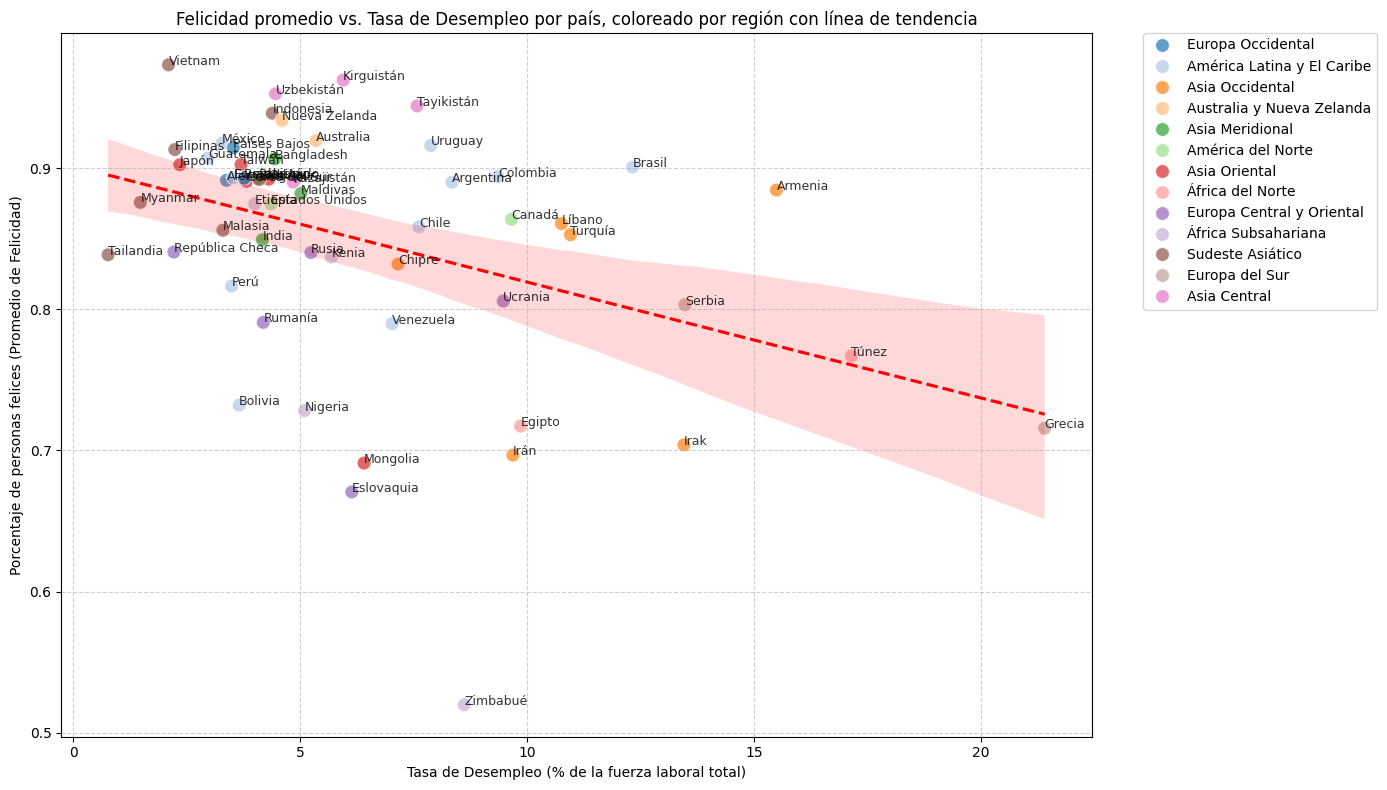

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular el promedio de 'Felicidad' y la Tasa de Desempleo por país y región
happiness_unemployment_by_country = copia_datos.groupby(['País', 'Región'])[['Felicidad', 'Desempleo']].mean().reset_index()

# Crear el gráfico de dispersión
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=happiness_unemployment_by_country,
    x='Desempleo',
    y='Felicidad',
    hue='Región',
    s=100,
    alpha=0.7,
    palette='tab20'
)

# Añadir una línea de tendencia general
sns.regplot(
    data=happiness_unemployment_by_country,
    x='Desempleo',
    y='Felicidad',
    scatter=False,
    color='red',
    line_kws={'linestyle':'--'},
    ci=95
)

# Añadir etiquetas de texto para cada país
for i, row in happiness_unemployment_by_country.iterrows():
    plt.text(row['Desempleo'], row['Felicidad'], row['País'], fontsize=9, alpha=0.8)

plt.title('Felicidad promedio vs. Tasa de Desempleo por país, coloreado por región con línea de tendencia')
plt.xlabel('Tasa de Desempleo (% de la fuerza laboral total)')
plt.ylabel('Porcentaje de personas felices (Promedio de Felicidad)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

A mayor tasa de desempleo menor porcentaje de personas felices hay en un país. Grecia como es un caso extremo, país europeo que pasó por una crisis económicas en la década pasada y altas tasas de desempleo que incidió en el estado de felicidad del país.

Procedemos a comprobar la correlación Felicidad y la tasa de desempleo calculando los coeficientes de Pearson y Spearman:

In [ ]:
# Seleccionar las columnas de interés
df_correlation = copia_datos[['Felicidad', 'Desempleo']].dropna()

# Verificar si hay suficientes datos después de eliminar NaNs
if len(df_correlation) > 1:
    # Correlación de Pearson
    pearson_corr, pearson_p_value = pearsonr(df_correlation['Felicidad'], df_correlation['Desempleo'])
    print(f"Correlación de Pearson entre Felicidad y Tasa de Desempleo: {pearson_corr:.4f}")
    print(f"Valor p (Pearson): {pearson_p_value:.4f}")
    if pearson_p_value < 0.05:
        print("La correlación de Pearson es estadísticamente significativa (p < 0.05).")
    else:
        print("La correlación de Pearson no es estadísticamente significativa (p >= 0.05).")

    print("\n" + "-"*50 + "\n")

    # Correlación de Spearman
    spearman_corr, spearman_p_value = spearmanr(df_correlation['Felicidad'], df_correlation['Desempleo'])
    print(f"Correlación de Spearman entre Felicidad y Tasa de Desempleo: {spearman_corr:.4f}")
    print(f"Valor p (Spearman): {spearman_p_value:.4f}")
    if spearman_p_value < 0.05:
        print("La correlación de Spearman es estadísticamente significativa (p < 0.05).")
    else:
        print("La correlación de Spearman no es estadísticamente significativa (p >= 0.05).")
else:
    print("No hay suficientes datos para calcular la correlación después de eliminar los valores NaN.")

Correlación de Pearson entre Felicidad y Tasa de Desempleo: -0.0848
Valor p (Pearson): 0.0000
La correlación de Pearson es estadísticamente significativa (p < 0.05).

--------------------------------------------------

Correlación de Spearman entre Felicidad y Tasa de Desempleo: -0.0803
Valor p (Spearman): 0.0000
La correlación de Spearman es estadísticamente significativa (p < 0.05).


Los coeficientes de Pearson y Spearman revelan que la correlación entre felicidad y la tasa de desempleo es es muy débil o casi nula.

**Felicidad versus Índice de Percepción de Corrupción**

El Índice de Percepción de Corrupción (IPC) de Transparencia Internacional clasifica a países según el nivel percibido de corrupción en su sector público, usando una escala de 0 (muy corrupto) a 100 (muy limpio/honesto).

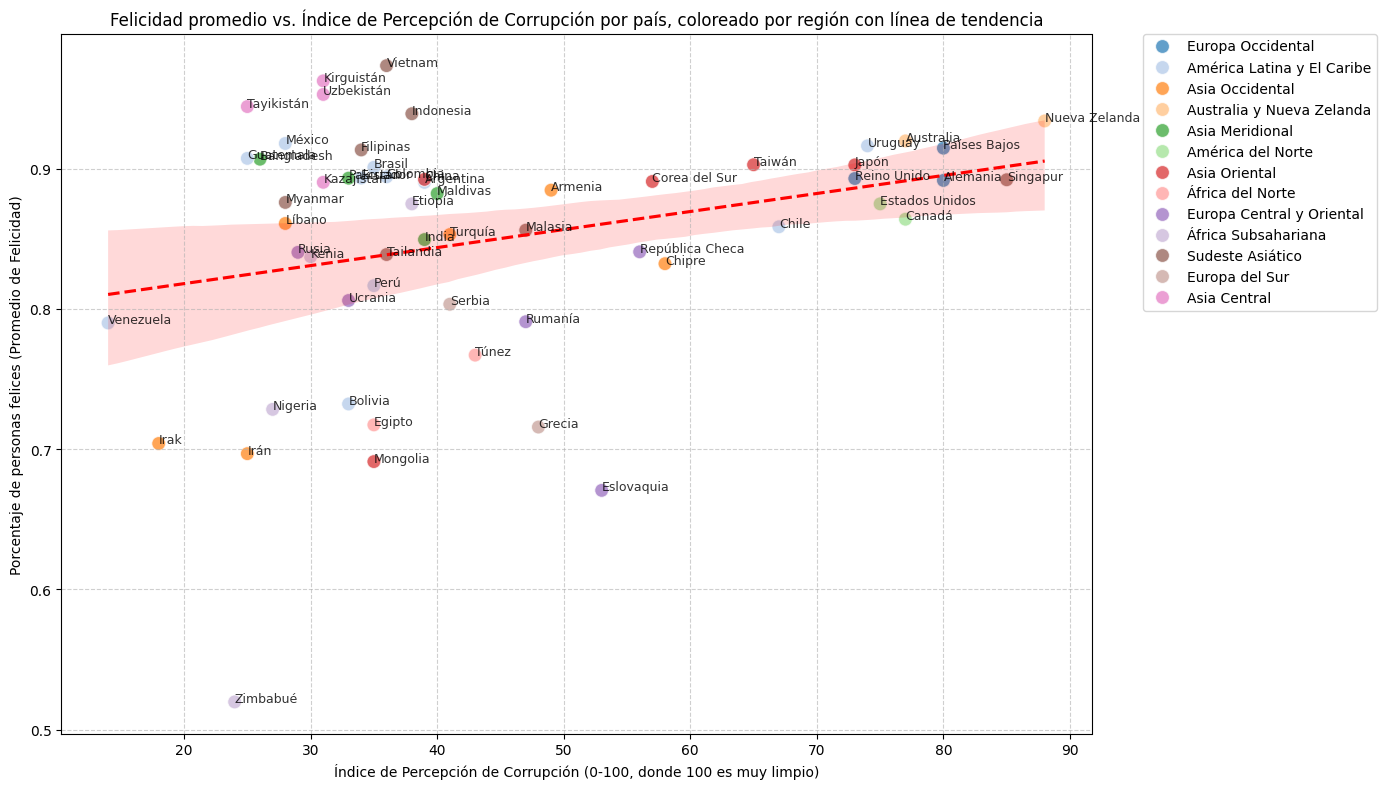

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular el promedio de 'Felicidad' y el Índice de Percepción de Corrupción por país y región
happiness_corruption_by_country = copia_datos.groupby(['País', 'Región'])[['Felicidad', 'Corrupción']].mean().reset_index()

# Crear el gráfico de dispersión
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=happiness_corruption_by_country,
    x='Corrupción',
    y='Felicidad',
    hue='Región',
    s=100,
    alpha=0.7,
    palette='tab20'
)

# Añadir una línea de tendencia general
sns.regplot(
    data=happiness_corruption_by_country,
    x='Corrupción',
    y='Felicidad',
    scatter=False,
    color='red',
    line_kws={'linestyle':'--'},
    ci=95
)

# Añadir etiquetas de texto para cada país
for i, row in happiness_corruption_by_country.iterrows():
    plt.text(row['Corrupción'], row['Felicidad'], row['País'], fontsize=9, alpha=0.8)

plt.title('Felicidad promedio vs. Índice de Percepción de Corrupción por país, coloreado por región con línea de tendencia')
plt.xlabel('Índice de Percepción de Corrupción (0-100, donde 100 es muy limpio)')
plt.ylabel('Porcentaje de personas felices (Promedio de Felicidad)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

A mayor índice de percepción de corrupción, es decir menos corrupción percibida por el ciudadano en el sector público de un país, mayor proporción de personas felices hay. Sin embargo, hay varios países atípicos, por ejemplo los de Asia Central y Sudeste Asiático donde la ciudadanía percibe mayor corrupción, pero hay más personas felices que en los lugares donde se percibe menos corrupción.

Procedemos a comprobar la correlación Felicidad y el Índice de Percepción de Corrupción calculando los coeficientes de Pearson y Spearman:

In [ ]:
# Seleccionar las columnas de interés
df_correlation = copia_datos[['Felicidad', 'Corrupción']].dropna()

# Verificar si hay suficientes datos después de eliminar NaNs
if len(df_correlation) > 1:
    # Correlación de Pearson
    pearson_corr, pearson_p_value = pearsonr(df_correlation['Felicidad'], df_correlation['Corrupción'])
    print(f"Correlación de Pearson entre Felicidad y Percepción de Corrupción: {pearson_corr:.4f}")
    print(f"Valor p (Pearson): {pearson_p_value:.4f}")
    if pearson_p_value < 0.05:
        print("La correlación de Pearson es estadísticamente significativa (p < 0.05).")
    else:
        print("La correlación de Pearson no es estadísticamente significativa (p >= 0.05).")

    print("\n" + "-"*50 + "\n")

    # Correlación de Spearman
    spearman_corr, spearman_p_value = spearmanr(df_correlation['Felicidad'], df_correlation['Corrupción'])
    print(f"Correlación de Spearman entre Felicidad y Percepción de Corrupción: {spearman_corr:.4f}")
    print(f"Valor p (Spearman): {spearman_p_value:.4f}")
    if spearman_p_value < 0.05:
        print("La correlación de Spearman es estadísticamente significativa (p < 0.05).")
    else:
        print("La correlación de Spearman no es estadísticamente significativa (p >= 0.05).")
else:
    print("No hay suficientes datos para calcular la correlación después de eliminar los valores NaN.")

Correlación de Pearson entre Felicidad y Percepción de Corrupción: 0.0651
Valor p (Pearson): 0.0000
La correlación de Pearson es estadísticamente significativa (p < 0.05).

--------------------------------------------------

Correlación de Spearman entre Felicidad y Percepción de Corrupción: 0.0629
Valor p (Spearman): 0.0000
La correlación de Spearman es estadísticamente significativa (p < 0.05).


Los coeficientes de Pearson y Spearman revelan que la correlación entre felicidad y el índice de perceción de corrupción es es muy débil o casi nula.

## **Modelo 1: Random Forest**

Preparar variables

In [ ]:
# Variable objetivo
y = copia_datos["Felicidad"]

# Variables independientes (excluyendo variables que no interesan para el análisis y las etiquetas creadas para visualización)
X = copia_datos.drop(columns=["Felicidad", "S006", "S007", "MODE", "S022", "S023", "S020", "S017",
                                "S018", "X050B", "X003R2", "X002", "X025R", "X025CSWVS", "F025", "X002_02A",
                                "V001A", "V002A", "X047R_WVS", "G016", "S012", "S010", "S011A", "S011B", "X048WVS",
                                "S013", "S013B", "E179WVS", "E179_WVS7LOC", "Región",
                                "grupoetario_etiqueta", "tipo_hogar", "educ_etiqueta", "estatuslaboral_etiqueta",
                                "nivelingresos_etiqueta", "clasesocial_etiqueta", "tradrat5", "survself", "TradAgg", "SurvSAgg"])

Definir grupos

In [ ]:
groups = copia_datos["País"]


Split por país

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


In [ ]:
print(f"Número de países únicos en el conjunto de entrenamiento: {groups.iloc[train_idx].nunique()}")
print(f"Número de países únicos en el conjunto de prueba: {groups.iloc[test_idx].nunique()}")


Número de países únicos en el conjunto de entrenamiento: 45
Número de países únicos en el conjunto de prueba: 12


In [ ]:
print("Países en el conjunto de entrenamiento:")
for country in sorted(groups.iloc[train_idx].unique()):
    print(f"- {country}")

print("\nPaíses en el conjunto de prueba:")
for country in sorted(groups.iloc[test_idx].unique()):
    print(f"- {country}")

Países en el conjunto de entrenamiento:
- Argentina
- Armenia
- Bangladesh
- Brasil
- Canadá
- Chile
- China
- Chipre
- Colombia
- Egipto
- Eslovaquia
- Estados Unidos
- Etiopía
- Filipinas
- Grecia
- Guatemala
- India
- Indonesia
- Irak
- Irán
- Japón
- Kazajistán
- Kirguistán
- Líbano
- Mongolia
- Myanmar
- Nigeria
- Nueva Zelanda
- Pakistán
- Países Bajos
- Perú
- Reino Unido
- República Checa
- Rumanía
- Rusia
- Serbia
- Tailandia
- Tayikistán 
- Turquía
- Túnez
- Ucrania
- Uruguay
- Uzbekistán
- Venezuela
- Zimbabué

Países en el conjunto de prueba:
- Alemania
- Australia
- Bolivia
- Corea del Sur
- Ecuador
- Kenia
- Malasia
- Maldivas
- México
- Singapur
- Taiwán
- Vietnam


In [ ]:
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")


Dimensiones de X_train: (68528, 285)
Dimensiones de X_test: (17586, 285)


Definir imputación de valores perdidos en las variables categóricas correspondientes. Se usará la moda por país como primera opción, sino la moda global.

In [ ]:
class GroupImputer(BaseEstimator, TransformerMixin):
    def __init__(self, group_column, numerical_cols, categorical_cols):
        self.group_column = group_column
        self.numerical_cols = numerical_cols
        self.categorical_cols = categorical_cols
        self.imputation_values = {}
        self.global_imputation_values = {}

    def fit(self, X, y=None):
        # Calcular media y moda global
        for col in self.numerical_cols:
            self.global_imputation_values[col] = X[col].mean()
        for col in self.categorical_cols:
            # Usar moda en los valores perdidos
            mode_val = X[col].mode()
            self.global_imputation_values[col] = mode_val[0] if not mode_val.empty else np.nan # Use np.nan if no mode

        # Calcular la media y moda por grupo
        grouped = X.groupby(self.group_column)
        for group_name, group_df in grouped:
            self.imputation_values[group_name] = {}
            for col in self.numerical_cols:
                group_mean = group_df[col].mean()
                # Usea media global si en el grupo hay un NaN
                self.imputation_values[group_name][col] = group_mean if not pd.isna(group_mean) else self.global_imputation_values[col]
            for col in self.categorical_cols:
                group_mode = group_df[col].mode()
                # Usar moda global si el en grupo hay un NaN
                self.imputation_values[group_name][col] = group_mode[0] if not group_mode.empty else self.global_imputation_values[col]
        return self

    def transform(self, X):
        X_transformed = X.copy()
        for group_name, group_impute_values in self.imputation_values.items():
            # Encuentra filas que pertenezcan a este grupo
            group_mask = (X_transformed[self.group_column] == group_name)
            for col in self.numerical_cols + self.categorical_cols:
                # imputa los valores NaN dentro de este grupo
                if col in group_impute_values:
                    X_transformed.loc[group_mask, col] = X_transformed.loc[group_mask, col].fillna(group_impute_values[col])

        # Tratar el resto de los NaNs imputando valores globales
        # Esto es para los grupos en los datos de prueba no vistos en entrenamiento
        for col in self.numerical_cols:
            X_transformed[col] = X_transformed[col].fillna(self.global_imputation_values[col])
        for col in self.categorical_cols:
            X_transformed[col] = X_transformed[col].fillna(self.global_imputation_values[col])

        # Eliminar la columna group después de realizar la imputación
        X_transformed = X_transformed.drop(columns=[self.group_column])
        return X_transformed

# Definir columnas numéricas para imputación con la media que están presentes en los datos de entrenamiento
explicit_numerical_mean_cols = ['tamañohogar', 'PIB/capita', 'Corrupción', 'Gini', 'Desempleo']

# Filtrar estas listas contra las columnas actuales en X_train (set de entrenamiento)
actual_numerical_mean_cols = [col for col in explicit_numerical_mean_cols if col in X_train.columns]

# Todas las otras columnas en X_train que no son 'País' y no están en actual_numerical_mean_cols serán categóricas e imputadas con la moda
actual_categorical_mode_cols = [col for col in X_train.columns if col not in actual_numerical_mean_cols and col != 'País']

# Definir el los pasos para imputar
imputer_pipeline_step = GroupImputer(
    group_column='País',
    numerical_cols=actual_numerical_mean_cols,
    categorical_cols=actual_categorical_mode_cols
)

print("GroupImputer definido para realizar imputación por país.")


GroupImputer definido para realizar imputación por país.


Las siguientes variables son nominales y se procede a codificarlas por medio de one hot encoding. De esta forma el modelo entiende mejor los valores numéricos, ya que sino interpretaría los valores categóricos como numéricos continuos. Las variables categóricas ordinales se dejaron igual porque el orden sí importa y se derivan de preguntas valoradas con una escala Likert.

In [ ]:
# Lista de columnas a convertir a variables dummy (one-hot encoding)
nominal_categorical_cols = [
    'E285', 'E283', 'E282', 'F201', 'G056', 'E288', 'F200', 'A106', 'E143',
    'B008', 'E026', 'E034', 'E287', 'E025', 'G054', 'G057', 'A106D', 'E027',
    'E289', 'G060', 'X044', 'G058', 'G055', 'G053', 'E018', 'E286', 'F034',
    'E001', 'G059', 'E015', 'E016', 'H008_07', 'E277', 'E003', 'A106B',
    'H008_08', 'E005', 'A104', 'A106C', 'F028B', 'A103', 'A105', 'A101',
    'A102', 'A100', 'F028', 'A099', 'A098', 'G027A', 'X001', 'X050C', 'estadocivil',
    'estatuslaboral', 'ocupación', 'ocupación_esposo', 'estatuslaboral_esposo', 'etnia',
    'ocupación_padre', 'X052'
]

print("Listas de columnas para One-Hot Encoding definidas.")


Listas de columnas para One-Hot Encoding definidas.


Gráfico de la distribución de clases de la variable Felicidad en datos de entrenamiento y prueba

Distribución de la variable 'Felicidad' en los datos de entrenamiento:
           Frecuencia  Porcentaje
Felicidad                        
1.0             58087   84.763892
0.0             10441   15.236108


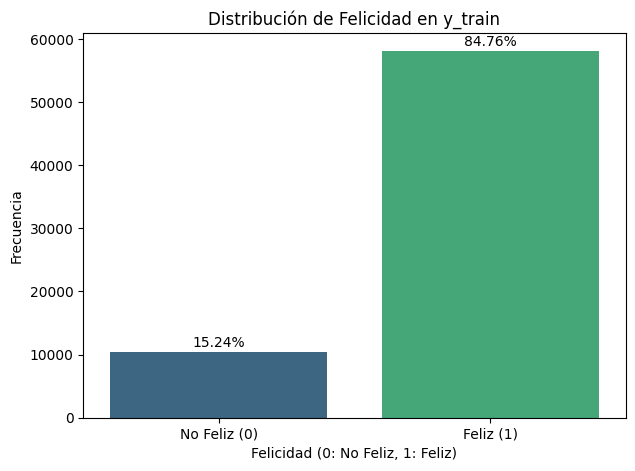


Distribución de la variable 'Felicidad' en en los datos de prueba:
           Frecuencia  Porcentaje
Felicidad                        
1.0             15436   87.774366
0.0              2150   12.225634


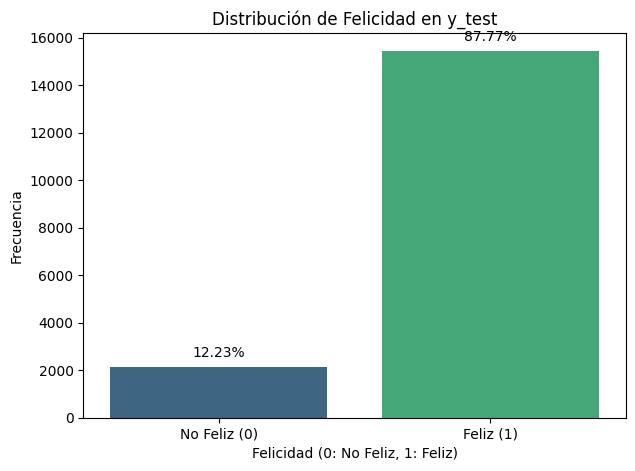

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribución para y_train
print("Distribución de la variable 'Felicidad' en los datos de entrenamiento:")
value_counts_train = y_train.value_counts(dropna=False)
percentage_train = y_train.value_counts(normalize=True, dropna=False) * 100
result_df_train = pd.DataFrame({'Frecuencia': value_counts_train, 'Porcentaje': percentage_train})
print(result_df_train)

plt.figure(figsize=(7, 5))
sns.countplot(x=y_train, palette='viridis', hue=y_train, legend=False)
total_train = len(y_train)
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width()/2.,
                    height + 300,
                    '{:1.2f}%'.format(100*height/total_train),
                    ha='center', va='bottom')
plt.title('Distribución de Felicidad en y_train')
plt.xlabel('Felicidad (0: No Feliz, 1: Feliz)')
plt.ylabel('Frecuencia')
plt.xticks([0, 1], ['No Feliz (0)', 'Feliz (1)'])
plt.show()


# Distribución para y_test
print("\nDistribución de la variable 'Felicidad' en en los datos de prueba:")
value_counts_test = y_test.value_counts(dropna=False)
percentage_test = y_test.value_counts(normalize=True, dropna=False) * 100
result_df_test = pd.DataFrame({'Frecuencia': value_counts_test, 'Porcentaje': percentage_test})
print(result_df_test)

plt.figure(figsize=(7, 5))
sns.countplot(x=y_test, palette='viridis', hue=y_test, legend=False)
total_test = len(y_test)
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width()/2.,
                    height + 300,
                    '{:1.2f}%'.format(100*height/total_test),
                    ha='center', va='bottom')
plt.title('Distribución de Felicidad en y_test')
plt.xlabel('Felicidad (0: No Feliz, 1: Feliz)')
plt.ylabel('Frecuencia')
plt.xticks([0, 1], ['No Feliz (0)', 'Feliz (1)'])
plt.show()


Preprocesamiento de los datos antes de definir el modelo Random Forest

In [ ]:
# Recrear X_train y X_test para incluir la columna 'País' para el GroupImputer
# El GroupImputer espera que la columna del grupo sea parte del DataFrame de entrada X.
# Usamos .copy() para asegurarnos de trabajar con DataFrames mutables para la entrada del pipeline.
X_train_pipe_input = X.iloc[train_idx].copy()
X_train_pipe_input['País'] = groups.iloc[train_idx].values # .values para evitar posibles problemas de alineación
X_test_pipe_input = X.iloc[test_idx].copy()
X_test_pipe_input['País'] = groups.iloc[test_idx].values # .values para evitar posibles problemas de alineación

# El GroupImputer (imputer_pipeline_step) ya está definido y se encarga de la imputación numérica y categórica
# y luego elimina la columna 'País' de su salida.

# Identificar columnas para One-Hot Encoding y passthrough después del paso de GroupImputer
# Estas listas deben reflejar las columnas que estarán presentes *después* de que se haya ejecutado el GroupImputer.
# Las columnas que quedan después del GroupImputer son todas las columnas de X, excluyendo 'País'.
cols_after_group_imputer = [col for col in X_train_pipe_input.columns if col != 'País']

# Filtrar nominal_categorical_cols para incluir solo aquellas realmente presentes en los datos después de la imputación
ohe_features_final = [col for col in nominal_categorical_cols if col in cols_after_group_imputer]

# Todas las demás columnas son numéricas o categóricas ordinales, y deben pasarse directamente
passthrough_features_final = [col for col in cols_after_group_imputer if col not in ohe_features_final]

# Crear el ColumnTransformer para la codificación one-hot y el passthrough para otras características
preprocessor_for_pipeline = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), ohe_features_final),
        ('num_ord', 'passthrough', passthrough_features_final)
    ],
    remainder='drop' # Eliminar cualquier columna no manejada explícitamente (no debería haber ninguna si las listas son correctas)
)


Definición del modelo Random Forest

In [ ]:
# Definir el RandomForestClassifier con class_weight='balanced' para el desbalance de clases
rf_model = RandomForestClassifier( n_estimators=100, max_depth=15, min_samples_leaf=4, min_samples_split=5, max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=1)

# Crear el pipeline completo que incluye solo el RandomForestClassifier
# Los pasos de imputación y preprocesamiento se realizarán antes
full_pipeline = Pipeline([
    ('random_forest', rf_model)                   # Clasificador Random Forest
])

# Definir GroupKFold para la validación cruzada, usando 'País' como variable de agrupación
group_kfold = GroupKFold(n_splits=3)


Aplicar antes el one-hot-encoder y el imputer para agilizar el modelo.

In [ ]:
# Primero, aplicar el imputer personalizado en X_train_pipe_input
# Necesitamos ajustar el imputer en los datos de entrenamiento y luego transformar tanto el entrenamiento como la prueba.
# La columna 'País' será usada por el imputer y luego eliminada de la salida.
imputer_pipeline_step.fit(X_train_pipe_input, y_train)
X_train_imputed = imputer_pipeline_step.transform(X_train_pipe_input)
X_test_imputed = imputer_pipeline_step.transform(X_test_pipe_input)

# Ahora, aplicar el preprocesador (OneHotEncoder y passthrough) en los datos ya imputados
# Necesitamos ajustar el preprocesador en los datos de entrenamiento imputados y luego transformar ambos.
preprocessor_for_pipeline.fit(X_train_imputed)
X_train_processed = preprocessor_for_pipeline.transform(X_train_imputed)
X_test_processed = preprocessor_for_pipeline.transform(X_test_imputed)

# Convertir las salidas del preprocesador (que pueden ser matrices dispersas) a DataFrames densos
# Esto es útil para la inspección y para modelos que prefieren entrada densa.
# Asegurarse de mantener los nombres de las columnas para los datos procesados
feature_names_after_preprocessing = preprocessor_for_pipeline.get_feature_names_out()
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names_after_preprocessing, index=X_train_pipe_input.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names_after_preprocessing, index=X_test_pipe_input.index)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [53] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
print(f"El set de entrenamiento después de aplicar el one-hot encoding tiene {X_train_processed.shape[1]} variables.")

El set de entrenamiento después de aplicar el one-hot encoding tiene 705 variables.


Evaluación del modelo Random Forest con validación cruzada

In [ ]:
# Métricas múltiples
scoring = {
    'f1': 'f1',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc'
}

# Evaluación con cross validation
cv_results = cross_validate(
    estimator=full_pipeline,                   # El pipeline que contiene solo el RandomForestClassifier
    X=X_train_processed,                       # Datos de entrenamiento ya preprocesados
    y=y_train,                                 # Variable objetivo de entrenamiento
    cv=group_kfold,                            # Objeto GroupKFold para la validación cruzada
    groups=groups.iloc[train_idx],             # Grupos para GroupKFold
    scoring=scoring,                           # Múltiples métricas de evaluación
    n_jobs=-1,                                 # Usar todos los núcleos de CPU disponibles
    verbose=1,                                 # Mostrar salida detallada
    return_train_score=True                    # Modificado a True para obtener las puntuaciones de entrenamiento
)

print("\n--- Resultados de Cross-Validation ---")
# Resultados promedio de test
for metric in scoring.keys():
    print(f"Test {metric.capitalize()}: {cv_results['test_' + metric].mean():.4f}")

# Resultados promedio de entrenamiento
print("\n--- Resultados de Entrenamiento de Cross-Validation ---")
for metric in scoring.keys():
    print(f"Train {metric.capitalize()}: {cv_results['train_' + metric].mean():.4f}")

# Ajusta el pipeline en todo el set de entrenamiento para obtener el modelo final para predicción e importancia de características
print("\nEntrenando el modelo final en todo el conjunto de datos de entrenamiento...")
full_pipeline.fit(X_train_processed, y_train)
print("Modelo final entrenado.")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.4min finished



--- Resultados de Cross-Validation ---
Test F1: 0.9217
Test Accuracy: 0.8622
Test Precision: 0.8840
Test Recall: 0.9634
Test Roc_auc: 0.8297

--- Resultados de Entrenamiento de Cross-Validation ---
Train F1: 0.9889
Train Accuracy: 0.9814
Train Precision: 0.9894
Train Recall: 0.9885
Train Roc_auc: 0.9969

Entrenando el modelo final en todo el conjunto de datos de entrenamiento...
Modelo final entrenado.


Evaluación del modelo Random Forest con datos de prueba

In [ ]:
# Predecir en el conjunto de prueba con el modelo final entrenado
# Usar los datos de prueba ya preprocesados
y_pred = full_pipeline.predict(X_test_processed)
y_proba = full_pipeline.predict_proba(X_test_processed)[:, 1] # Probabilidad de la clase positiva

Métricas de evaluación del modelo Random Forest con datos de prueba


Evaluación del modelo en el conjunto de prueba:
Accuracy: 0.8831
Precision: 0.9041
Recall: 0.9697
F1-score: 0.9358
ROC-AUC: 0.8409

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.55      0.26      0.35      2150
         1.0       0.90      0.97      0.94     15436

    accuracy                           0.88     17586
   macro avg       0.73      0.62      0.64     17586
weighted avg       0.86      0.88      0.86     17586


Matriz de Confusión:
[[  562  1588]
 [  467 14969]]


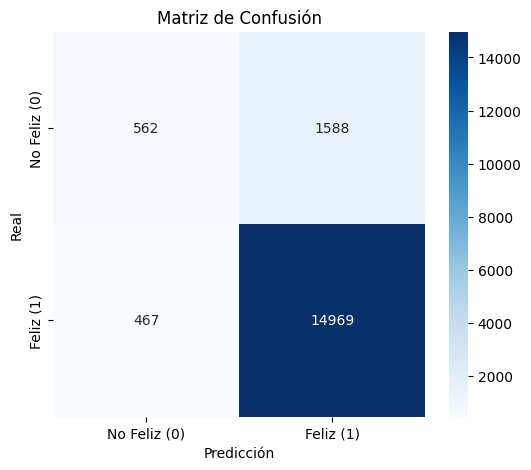

In [ ]:
# Calcular y mostrar las métricas de evaluación en el conjunto de prueba
print("\nEvaluación del modelo en el conjunto de prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# Reporte de Clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusión:")
print(cm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=['No Feliz (0)', 'Feliz (1)'],
            yticklabels=['No Feliz (0)', 'Feliz (1)'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()


Curva ROC con los datos de prueba:

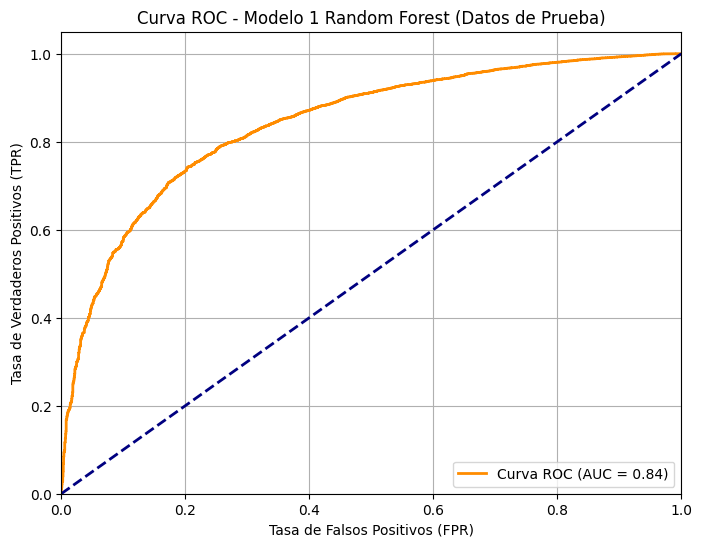

In [ ]:
from sklearn.metrics import roc_curve, auc

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelo 1 Random Forest (Datos de Prueba)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Los resultados de las métricas de evaluación fueron los siguientes: en la validación cruzada el F1 resultó en 0.9217, Recall en 0.9634 y AUC (área bajo la curva ROC) en 0.8297. Al comparar con los resultados en la fase de prueba del modelo, F1 rindió en 0.9358, Recall 0.9697 y AUC 0.8409.

Variables más importantes predictoras de la felicidad según el modelo Random Forest

In [ ]:
# Importancia de las características del modelo (Feature Importance)
print("\nCalculando la Importancia de las Características del modelo Random Forest")

# Acceder al modelo Random Forest dentro del pipeline
rf_model_final = full_pipeline.named_steps['random_forest']

# Obtener la importancia de las características
importances = rf_model_final.feature_importances_

# Crear un DataFrame para visualizar las importancias
feature_importances_df = pd.DataFrame({
    'Feature': feature_names_after_preprocessing,
    'Importance': importances
})

# Ordenar las características por importancia de forma descendente
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Seleccionar las top 25 características
top_25_features = feature_importances_df.head(25)

print("\nTop 25 Importancia de las Características:")
for index, row in top_25_features.iterrows():
    print(f"{row['Feature']:<30}: {row['Importance']:.4f}")



Calculando la Importancia de las Características del modelo Random Forest

Top 25 Importancia de las Características:
num_ord__satisfacciónvital    : 0.0861
num_ord__estadodesalud        : 0.0618
num_ord__satisfacciónfinanciera: 0.0523
num_ord__libertaddeelección   : 0.0246
num_ord__escasezdinero        : 0.0146
num_ord__escasezmedicinas     : 0.0128
num_ord__barrioseguro         : 0.0121
num_ord__movilidadeconómica   : 0.0115
num_ord__Desempleo            : 0.0112
num_ord__nivelingresos        : 0.0107
num_ord__escasezalimentos     : 0.0104
num_ord__Gini                 : 0.0087
num_ord__seguridadciudadana   : 0.0085
num_ord__PIB/capita           : 0.0084
num_ord__edad                 : 0.0081
num_ord__democracia           : 0.0081
num_ord__respetoDDHH          : 0.0080
num_ord__Corrupción           : 0.0079
num_ord__clasesocial          : 0.0070
num_ord__confianzafamilia     : 0.0063
num_ord__frecuenciasoborno    : 0.0060
num_ord__confianzagobierno    : 0.0057
num_ord__responsabilid

Visualización de las 25 variables más importantes

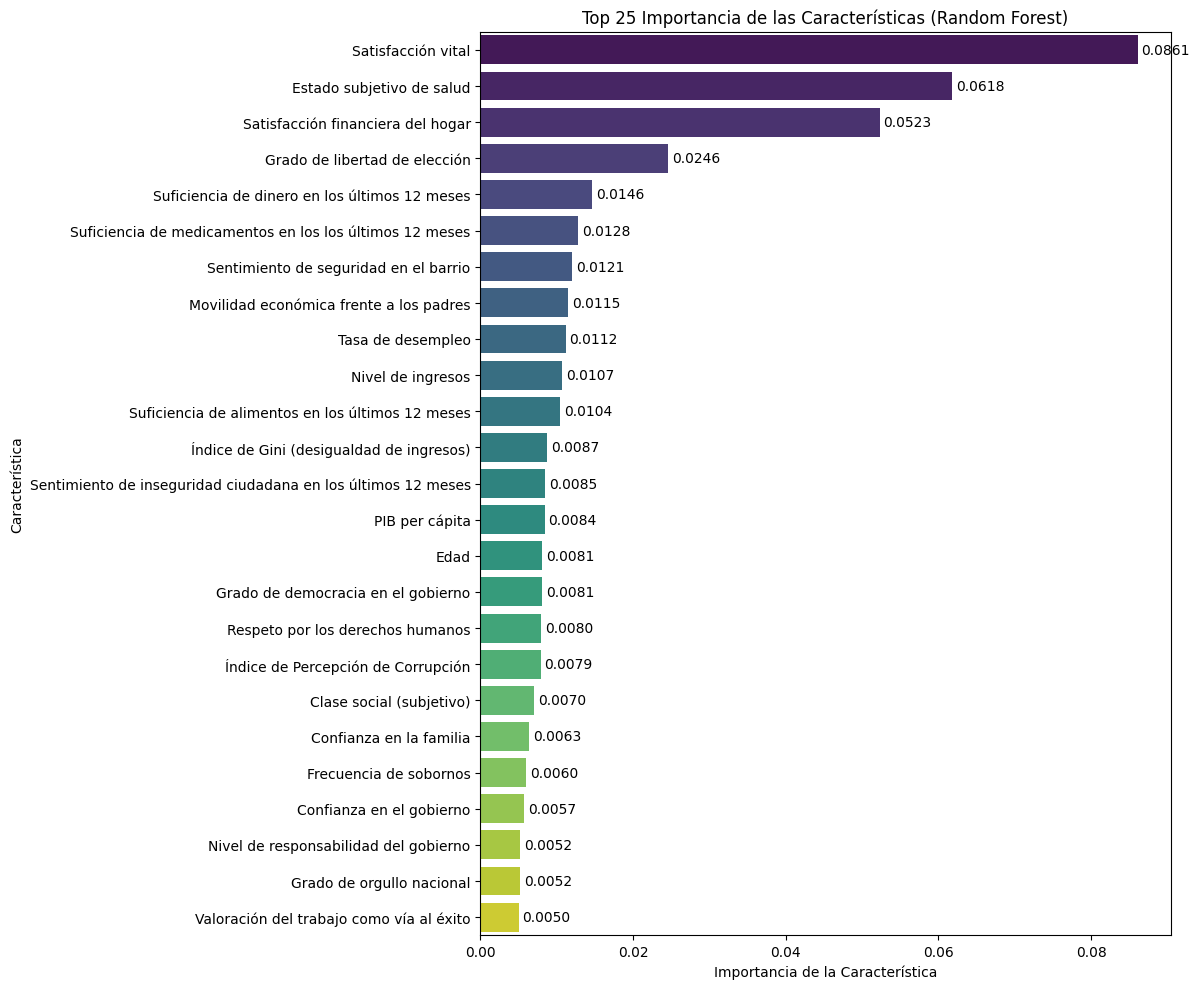

In [ ]:
new_labels = [
    "Satisfacción vital",
    "Estado subjetivo de salud",
    "Satisfacción financiera del hogar",
    "Grado de libertad de elección",
    "Suficiencia de dinero en los últimos 12 meses",
    "Suficiencia de medicamentos en los los últimos 12 meses",
    "Sentimiento de seguridad en el barrio",
    "Movilidad económica frente a los padres",
    "Tasa de desempleo",
    "Nivel de ingresos",
    "Suficiencia de alimentos en los últimos 12 meses",
    "Índice de Gini (desigualdad de ingresos)",
    "Sentimiento de inseguridad ciudadana en los últimos 12 meses",
    "PIB per cápita",
    "Edad",
    "Grado de democracia en el gobierno",
    "Respeto por los derechos humanos",
    "Índice de Percepción de Corrupción",
    "Clase social (subjetivo)",
    "Confianza en la familia",
    "Frecuencia de sobornos",
    "Confianza en el gobierno",
    "Nivel de responsabilidad del gobierno",
    "Grado de orgullo nacional",
    "Valoración del trabajo como vía al éxito"
]

# Asegurarse de que el número de etiquetas coincida con el número de características
if len(new_labels) == len(top_25_features):
    # Usar .loc para evitar SettingWithCopyWarning
    top_25_features.loc[:, 'Feature'] = new_labels
else:
    print(f"Advertencia: El número de etiquetas proporcionadas ({len(new_labels)}) no coincide con el número de características principales ({len(top_25_features)}).")

# Graficar las Top 25 Importancias de las Características con las nuevas etiquetas
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=top_25_features, palette='viridis', hue='Feature', legend=False)

# Añadir etiquetas de valor fuera de las barras en el extremo derecho
for p in plt.gca().patches:
    width = p.get_width() # Obtener la anchura de la barra (el valor de Importance)
    plt.gca().text(width + 0.0005, # Posicionar la etiqueta ligeramente a la derecha del borde de la barra
                   p.get_y() + p.get_height() / 2, # Centrar verticalmente en la barra
                   '{:1.4f}'.format(width), # Formatear el valor de importancia
                   ha='left', # Alineación horizontal a la izquierda
                   va='center', # Alineación vertical centrada
                   color='black', # Color de la fuente negro
                   fontsize=10) # Tamaño de la fuente

plt.xlabel("Importancia de la Característica")
plt.ylabel("Característica")
plt.title("Top 25 Importancia de las Características (Random Forest)")
plt.yticks(ticks=range(len(top_25_features)), labels=top_25_features['Feature'])
plt.tight_layout()
plt.show()

De esas 25 variables identificadas como importantes para predecir la felicidad con el modelo Random Forest, se procede ahora analizar la correlación de las mismas con felicidad.

In [ ]:
from scipy.stats import pearsonr

# Lista de variables a correlacionar con 'Felicidad'
variables_a_correlacionar = [
    'satisfacciónvital',
    'estadodesalud',
    'satisfacciónfinanciera',
    'libertaddeelección',
    'escasezdinero',
    'escasezmedicinas',
    'barrioseguro',
    'movilidadeconómica',
    'Desempleo',
    'nivelingresos',
    'escasezalimentos',
    'Gini',
    'seguridadciudadana',
    'PIB/capita',
    'edad',
    'democracia',
    'respetoDDHH',
    'Corrupción',
    'clasesocial',
    'confianzafamilia',
    'frecuenciasoborno',
    'confianzagobierno',
    'responsabilidadgobierno',
    'orgullonacional',
    'valordeltrabajo'
]

# DataFrame para almacenar los resultados
resultados_correlacion = []

# Calcular la correlación para cada variable
for var in variables_a_correlacionar:
    # Verificar si la variable existe en el DataFrame
    if var in copia_datos.columns:
        # Eliminar NaN para el cálculo de la correlación
        temp_df = copia_datos[['Felicidad', var]].dropna()
        if len(temp_df) > 1: # Se necesitan al menos 2 puntos para calcular la correlación
            correlation, p_value = pearsonr(temp_df['Felicidad'], temp_df[var])
            significativa = 'Sí' if p_value < 0.05 else 'No'
            resultados_correlacion.append({
                'Variable': var,
                'Correlación con Felicidad': correlation,
                'Valor p': p_value,
                'Estadísticamente Significativa': significativa
            })
        else:
            resultados_correlacion.append({
                'Variable': var,
                'Correlación con Felicidad': np.nan,
                'Valor p': np.nan,
                'Estadísticamente Significativa': 'No hay suficientes datos'
            })
    else:
        resultados_correlacion.append({
            'Variable': var,
            'Correlación con Felicidad': np.nan,
            'Valor p': np.nan,
            'Estadísticamente Significativa': 'Variable no encontrada'
        })

# Crear DataFrame y ordenar por correlación de mayor a menor
df_correlaciones = pd.DataFrame(resultados_correlacion)
df_correlaciones = df_correlaciones.sort_values(by='Correlación con Felicidad', ascending=False).reset_index(drop=True)

print("\nTabla de Correlaciones con 'Felicidad':")
print(df_correlaciones.to_string())



Tabla de Correlaciones con 'Felicidad':
                   Variable  Correlación con Felicidad        Valor p Estadísticamente Significativa
0         satisfacciónvital                   0.377164   0.000000e+00                             Sí
1    satisfacciónfinanciera                   0.300309   0.000000e+00                             Sí
2        libertaddeelección                   0.204485   0.000000e+00                             Sí
3             escasezdinero                   0.195279   0.000000e+00                             Sí
4          escasezalimentos                   0.182069   0.000000e+00                             Sí
5          escasezmedicinas                   0.177150   0.000000e+00                             Sí
6             nivelingresos                   0.150405   0.000000e+00                             Sí
7        seguridadciudadana                   0.126355  8.303732e-302                             Sí
8                democracia                   0.12

Las 25 correlaciones analizadas son estadísticamente significativas. No se encontró ninguna correlación fuerte, pero sí moderadas. Las variables con una correlación positiva moderada son satisfacción vital (0.38) y satisfacción con la situación financiera del hogar (0.30). La única variable con una correlación negativa moderada es el estado subjetivo de salud (-0.30).

Otra forma de extraer las características más importantes es con permutation_importance. Este método sirve para medir la importancia de cada característica (feature) en un modelo de Random Forest evaluando cómo disminuye la precisión (o métrica de rendimiento) del modelo cuando los valores de una característica se mezclan aleatoriamente.

En lugar de usar las importancias basadas en impurezas (Gini) que vienen por defecto con Random Forest, este método proporciona una forma más robusta para identificar qué variables realmente aportan capacidad predictiva. Las variables más importantes son aquellas cuya importancia media es mayor que su desviación estándar.

Es importante destacar que la importancia de las características por permutación (`permutation_importance`) se calculó utilizando el conjunto de prueba (`X_test_processed`, `y_test`). Esto se hace para obtener una medida más realista de cómo las características contribuyen a la capacidad de generalización del modelo, evitando estimaciones sobre-optimistas que podrían surgir del uso del conjunto de entrenamiento debido al sobreajuste.

In [ ]:
from sklearn.inspection import permutation_importance

print("Calculando Permutation Feature Importance para el Modelo 1...")

# Calcular la importancia de las características por permutación
# full_pipeline ya está ajustado en X_train_processed, y_train
result = permutation_importance(
    full_pipeline,
    X_test_processed,  # Usar el conjunto de prueba ya preprocesado
    y_test,
    n_repeats=10,      # Número de veces que se baraja una característica y se vuelve a calcular la puntuación
    random_state=42,
    n_jobs=-1          # Usar todos los núcleos disponibles
)

# Crear un DataFrame con los resultados
permutation_importances_df = pd.DataFrame({
    'Feature': X_test_processed.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
})

# Ordenar por la importancia media de forma descendente
permutation_importances_df = permutation_importances_df.sort_values(by='Importance_Mean', ascending=False)

# Mostrar las 25 características más importantes
print("\nTop 25 Características más importantes según Permutation Feature Importance (Modelo 1):")
# Ajustar el ancho de las columnas para una mejor visualización
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(permutation_importances_df.head(25).to_string(index=False))

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

Calculando Permutation Feature Importance para el Modelo 1...

Top 25 Características más importantes según Permutation Feature Importance (Modelo 1):
                        Feature  Importance_Mean  Importance_Std
     num_ord__satisfacciónvital         0.005499        0.000662
         num_ord__estadodesalud         0.003844        0.000444
num_ord__satisfacciónfinanciera         0.000887        0.000592
    num_ord__movilidadeconómica         0.000716        0.000658
                  cat__E003_2.0         0.000250        0.000120
               num_ord__E069_01         0.000245        0.000325
                  cat__F028_6.0         0.000239        0.000061
             cat__ocupación_7.0         0.000227        0.000095
                  num_ord__F199         0.000222        0.000156
                  cat__E282_2.0         0.000216        0.000154
                  num_ord__E012         0.000193        0.000175
                 num_ord__F114E         0.000176        0.000201
    

Luego de extraer características importantes con permutación, se observa que la satisfacción vital, estado de salud, satisfacción financiera con el hogar y movilidad económica (esta variable en realidad es estándares de vida mejor o peor que los padres) se mantienen como las más imporantes. La que se colocó en la posición número 5 ("E003_2.0") es una variable binaria donde 1 son aquellas personas que piensan que el pueblo debe tener voz en decisiones importantes del gobierno, en vez de mantener el orden público, proteger la libertad de expresión o combatir la inflación.

Se procede a continuación verificar la robustez del modelo reentrenándolo sin la variable satisfacción vital que resultó en una importancia alta.

## **Modelo 2: Random Forest (excluyendo 'satisfacciónvital')**

Preparar variables

In [ ]:
# Variable objetivo para el Modelo 2
y_2 = copia_datos["Felicidad"]

# Variables independientes para el Modelo 2 (excluyendo 'Felicidad', 'satisfacciónvital' y otras irrelevantes)
X_2 = copia_datos.drop(columns=["Felicidad", "satisfacciónvital", "S006", "S007", "MODE", "S022", "S023", "S020", "S017",
                                "S018", "X050B", "X003R2", "X002", "X025R", "X025CSWVS", "F025", "X002_02A",
                                "V001A", "V002A", "X047R_WVS", "G016", "S012", "S010", "S011A", "S011B", "X048WVS",
                                "S013", "S013B", "E179WVS", "E179_WVS7LOC", "Región", "grupoetario_etiqueta", "tipo_hogar",
                                "educ_etiqueta", "estatuslaboral_etiqueta", "nivelingresos_etiqueta", "clasesocial_etiqueta",
                                "tradrat5", "survself", "TradAgg", "SurvSAgg"])

# Definir grupos para el Modelo 2 (se mantiene 'País')
groups_2 = copia_datos["País"]

Split por país

In [ ]:
gss_2 = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx_2, test_idx_2 = next(gss_2.split(X_2, y_2, groups=groups_2))

X_train_2, X_test_2 = X_2.iloc[train_idx_2], X_2.iloc[test_idx_2]
y_train_2, y_test_2 = y_2.iloc[train_idx_2], y_2.iloc[test_idx_2]

print(f"Dimensiones de X_train_2: {X_train_2.shape}")
print(f"Dimensiones de X_test_2: {X_test_2.shape}")

Dimensiones de X_train_2: (68528, 284)
Dimensiones de X_test_2: (17586, 284)


Definir imputación y preprocesamiento

In [ ]:
# Recrear X_train_2 y X_test_2 para incluir la columna 'País' para el GroupImputer
X_train_pipe_input_2 = X_2.iloc[train_idx_2].copy()
X_train_pipe_input_2['País'] = groups_2.iloc[train_idx_2].values
X_test_pipe_input_2 = X_2.iloc[test_idx_2].copy()
X_test_pipe_input_2['País'] = groups_2.iloc[test_idx_2].values

# Definir columnas numéricas y categóricas para imputación (excluyendo 'satisfacciónvital')
explicit_numerical_mean_cols_2 = ['tamañohogar', 'PIB/capita', 'Corrupción', 'Gini', 'Desempleo']
actual_numerical_mean_cols_2 = [col for col in explicit_numerical_mean_cols_2 if col in X_train_2.columns]
actual_categorical_mode_cols_2 = [col for col in X_train_2.columns if col not in actual_numerical_mean_cols_2 and col != 'País']

# Definir el imputer para el Modelo 2
imputer_pipeline_step_2 = GroupImputer(
    group_column='País',
    numerical_cols=actual_numerical_mean_cols_2,
    categorical_cols=actual_categorical_mode_cols_2
)

# Filtrar nominal_categorical_cols para incluir solo aquellas realmente presentes en los datos después de la imputación
ohe_features_final_2 = [col for col in nominal_categorical_cols if col in X_train_2.columns and col != 'satisfacciónvital']
passthrough_features_final_2 = [col for col in X_train_2.columns if col not in ohe_features_final_2 and col not in actual_numerical_mean_cols_2 and col != 'País']

# Crear el ColumnTransformer para la codificación one-hot y el passthrough para otras características
preprocessor_for_pipeline_2 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), ohe_features_final_2),
        ('num_ord', 'passthrough', passthrough_features_final_2)
    ],
    remainder='drop'
)

Aplicar preprocesamiento: One-Hot-Encoding e Imputer

In [ ]:
# Aplicar el imputer personalizado en X_train_pipe_input_2 y X_test_pipe_input_2
imputer_pipeline_step_2.fit(X_train_pipe_input_2, y_train_2)
X_train_imputed_2 = imputer_pipeline_step_2.transform(X_train_pipe_input_2)
X_test_imputed_2 = imputer_pipeline_step_2.transform(X_test_pipe_input_2)

# Aplicar el preprocesador (OneHotEncoder y passthrough) en los datos ya imputados
preprocessor_for_pipeline_2.fit(X_train_imputed_2)
X_train_processed_2 = preprocessor_for_pipeline_2.transform(X_train_imputed_2)
X_test_processed_2 = preprocessor_for_pipeline_2.transform(X_test_imputed_2)

# Convertir las salidas del preprocesador a DataFrames densos
feature_names_after_preprocessing_2 = preprocessor_for_pipeline_2.get_feature_names_out()
X_train_processed_2 = pd.DataFrame(X_train_processed_2, columns=feature_names_after_preprocessing_2, index=X_train_pipe_input_2.index)
X_test_processed_2 = pd.DataFrame(X_test_processed_2, columns=feature_names_after_preprocessing_2, index=X_test_pipe_input_2.index)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [53] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Definición y Entrenamiento del Modelo Random Forest sin la variable satisfiacción vital

In [ ]:
# Definir el RandomForestClassifier con class_weight='balanced' para el desbalance de clases
rf_model_2 = RandomForestClassifier( n_estimators=100, max_depth=15, min_samples_leaf=4, min_samples_split=5, max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=1)

# Crear el pipeline completo que incluye solo el RandomForestClassifier
full_pipeline_2 = Pipeline([
    ('random_forest', rf_model_2)                   # Clasificador Random Forest
])

# Definir GroupKFold para la validación cruzada
group_kfold_2 = GroupKFold(n_splits=3)

# Métricas múltiples
scoring = {
    'f1': 'f1',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'roc_auc': 'roc_auc'
}

# Evaluación con cross validation
cv_results_2 = cross_validate(
    estimator=full_pipeline_2,
    X=X_train_processed_2,
    y=y_train_2,
    cv=group_kfold_2,
    groups=groups_2.iloc[train_idx_2],
    scoring=scoring,
    n_jobs=-1,
    verbose=1,
    return_train_score=True # Cambiado a True para incluir scores de entrenamiento
)

print("\n--- Resultados de Cross-Validation (Modelo 2) ---")
for metric in scoring.keys():
    print(f"{metric.capitalize()}: {cv_results_2['test_' + metric].mean():.4f}")

# Resultados promedio de entrenamiento
print("\n--- Resultados de Entrenamiento de Cross-Validation (Modelo 2) ---")
for metric in scoring.keys():
    print(f"Train {metric.capitalize()}: {cv_results_2['train_' + metric].mean():.4f}")

# Ajustar el pipeline en todo el set de entrenamiento para obtener el modelo final
print("\nEntrenando el modelo final en todo el conjunto de datos de entrenamiento (Modelo 2)...")
full_pipeline_2.fit(X_train_processed_2, y_train_2)
print("Modelo final (Modelo 2) entrenado.")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.2min finished



--- Resultados de Cross-Validation (Modelo 2) ---
F1: 0.9190
Accuracy: 0.8561
Precision: 0.8762
Recall: 0.9671
Roc_auc: 0.8012

--- Resultados de Entrenamiento de Cross-Validation (Modelo 2) ---
Train F1: 0.9891
Train Accuracy: 0.9815
Train Precision: 0.9873
Train Recall: 0.9908
Train Roc_auc: 0.9968

Entrenando el modelo final en todo el conjunto de datos de entrenamiento (Modelo 2)...
Modelo final (Modelo 2) entrenado.


Evaluación del modelo con datos de prueba


Evaluación del modelo en el conjunto de prueba (Modelo 2):
Accuracy: 0.8776
Precision: 0.9003
Recall: 0.9677
F1-score: 0.9328
ROC-AUC: 0.8126

Reporte de Clasificación (Modelo 2):
              precision    recall  f1-score   support

         0.0       0.50      0.23      0.32      2150
         1.0       0.90      0.97      0.93     15436

    accuracy                           0.88     17586
   macro avg       0.70      0.60      0.62     17586
weighted avg       0.85      0.88      0.86     17586


Matriz de Confusión (Modelo 2):
[[  496  1654]
 [  498 14938]]


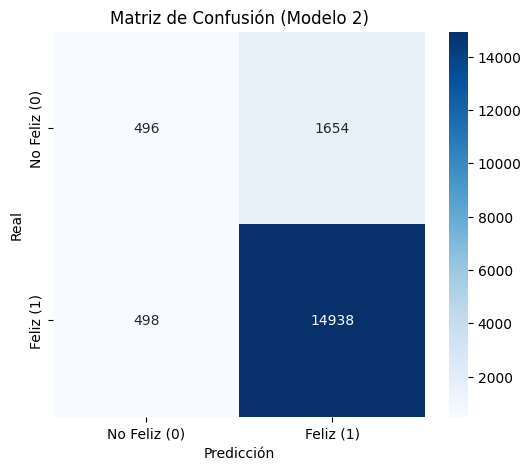

In [ ]:
# Predecir en el conjunto de prueba con el modelo final entrenado
y_pred_2 = full_pipeline_2.predict(X_test_processed_2)
y_proba_2 = full_pipeline_2.predict_proba(X_test_processed_2)[:, 1] # Probabilidad de la clase positiva

# Calcular y mostrar las métricas de evaluación en el conjunto de prueba
print("\nEvaluación del modelo en el conjunto de prueba (Modelo 2):")
print(f"Accuracy: {accuracy_score(y_test_2, y_pred_2):.4f}")
print(f"Precision: {precision_score(y_test_2, y_pred_2):.4f}")
print(f"Recall: {recall_score(y_test_2, y_pred_2):.4f}")
print(f"F1-score: {f1_score(y_test_2, y_pred_2):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_2, y_proba_2):.4f}")

# Reporte de Clasificación
print("\nReporte de Clasificación (Modelo 2):")
print(classification_report(y_test_2, y_pred_2))

# Matriz de Confusión
cm_2 = confusion_matrix(y_test_2, y_pred_2)
print("\nMatriz de Confusión (Modelo 2):")
print(cm_2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_2, annot=True, fmt='g', cmap='Blues',
            xticklabels=['No Feliz (0)', 'Feliz (1)'],
            yticklabels=['No Feliz (0)', 'Feliz (1)'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión (Modelo 2)')
plt.show()

###  Visualización de la evolución de las métricas en el Modelo 1 y 2 de Random Forest

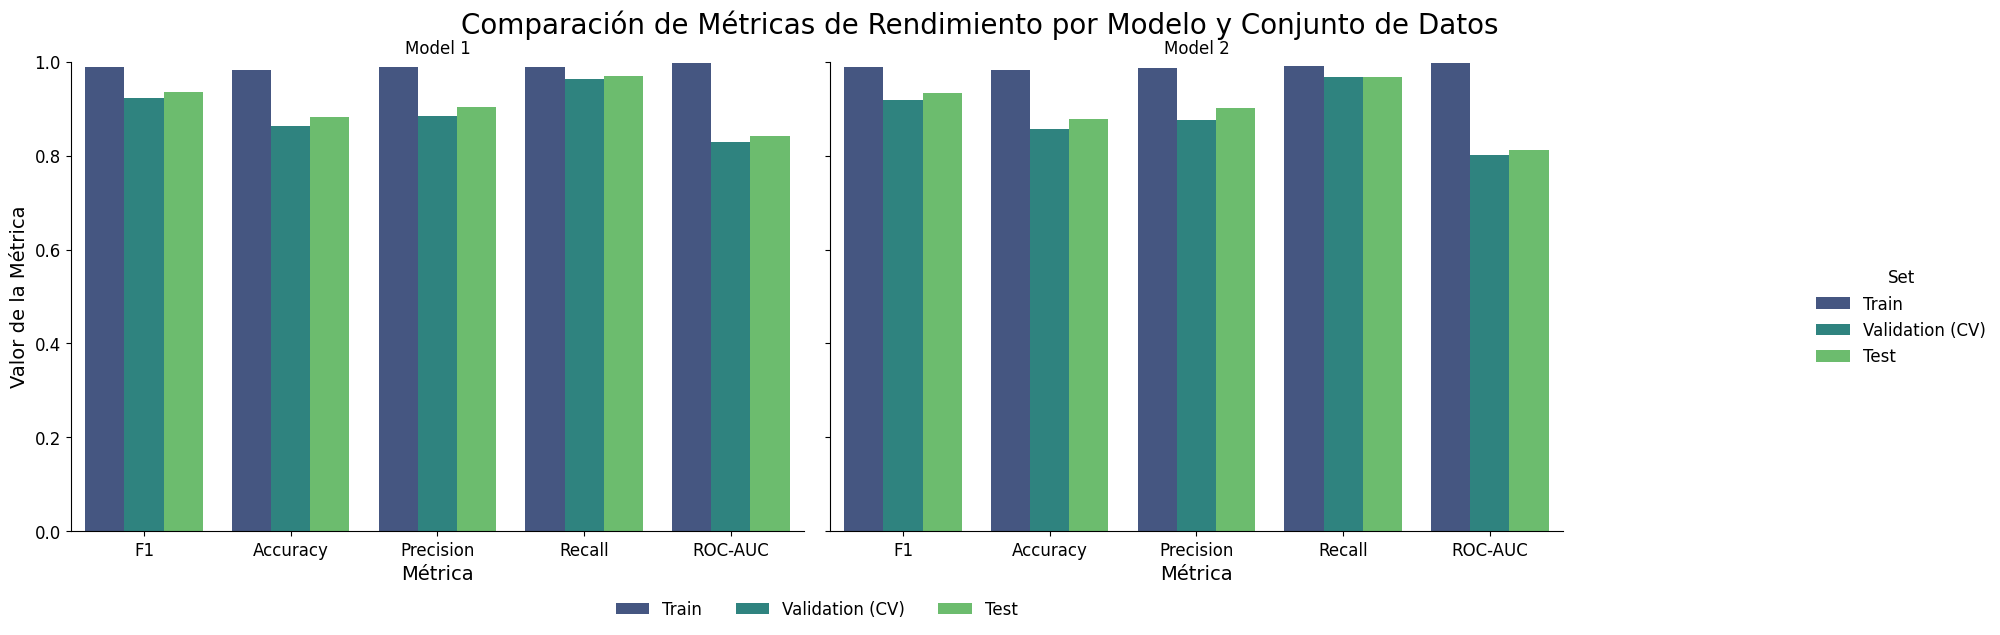

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Métricas para el Modelo 1 (con 'satisfacciónvital') ---

# Resultados de validación cruzada (de cv_results)
metrics_model1_cv = {
    'F1': cv_results['test_f1'].mean(),
    'Accuracy': cv_results['test_accuracy'].mean(),
    'Precision': cv_results['test_precision'].mean(),
    'Recall': cv_results['test_recall'].mean(),
    'ROC-AUC': cv_results['test_roc_auc'].mean()
}

# Resultados de entrenamiento (de cv_results)
metrics_model1_train = {
    'F1': cv_results['train_f1'].mean(),
    'Accuracy': cv_results['train_accuracy'].mean(),
    'Precision': cv_results['train_precision'].mean(),
    'Recall': cv_results['train_recall'].mean(),
    'ROC-AUC': cv_results['train_roc_auc'].mean()
}

# Resultados de prueba (de y_test, y_pred, y_proba)
metrics_model1_test = {
    'F1': f1_score(y_test, y_pred),
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

# --- Métricas para el Modelo 2 (sin 'satisfacciónvital') ---

# Resultados de validación cruzada (de cv_results_2)
metrics_model2_cv = {
    'F1': cv_results_2['test_f1'].mean(),
    'Accuracy': cv_results_2['test_accuracy'].mean(),
    'Precision': cv_results_2['test_precision'].mean(),
    'Recall': cv_results_2['test_recall'].mean(),
    'ROC-AUC': cv_results_2['test_roc_auc'].mean()
}

# Resultados de entrenamiento (de cv_results_2)
metrics_model2_train = {
    'F1': cv_results_2['train_f1'].mean(),
    'Accuracy': cv_results_2['train_accuracy'].mean(),
    'Precision': cv_results_2['train_precision'].mean(),
    'Recall': cv_results_2['train_recall'].mean(),
    'ROC-AUC': cv_results_2['train_roc_auc'].mean()
}

# Resultados de prueba (de y_test_2, y_pred_2, y_proba_2)
metrics_model2_test = {
    'F1': f1_score(y_test_2, y_pred_2),
    'Accuracy': accuracy_score(y_test_2, y_pred_2),
    'Precision': precision_score(y_test_2, y_pred_2),
    'Recall': recall_score(y_test_2, y_pred_2),
    'ROC-AUC': roc_auc_score(y_test_2, y_proba_2)
}

# Consolidar datos para graficar
data = []

for metric_name in metrics_model1_cv.keys():
    data.append({'Metric': metric_name, 'Value': metrics_model1_train[metric_name], 'Set': 'Train', 'Model': 'Model 1'})
    data.append({'Metric': metric_name, 'Value': metrics_model1_cv[metric_name], 'Set': 'Validation (CV)', 'Model': 'Model 1'})
    data.append({'Metric': metric_name, 'Value': metrics_model1_test[metric_name], 'Set': 'Test', 'Model': 'Model 1'})

    # Añadir puntuaciones de entrenamiento del Modelo 2
    data.append({'Metric': metric_name, 'Value': metrics_model2_train[metric_name], 'Set': 'Train', 'Model': 'Model 2'})
    data.append({'Metric': metric_name, 'Value': metrics_model2_cv[metric_name], 'Set': 'Validation (CV)', 'Model': 'Model 2'})
    data.append({'Metric': metric_name, 'Value': metrics_model2_test[metric_name], 'Set': 'Test', 'Model': 'Model 2'})

df_metrics = pd.DataFrame(data)

# Configurar el tamaño de la fuente base
plt.rcParams.update({'font.size': 12}) # Tamaño de fuente general para el plot

# Crear el gráfico de barras usando catplot para faceting
g = sns.catplot(x='Metric', y='Value', hue='Set', col='Model', data=df_metrics, kind='bar', palette='viridis', errorbar=None, height=6, aspect=1.2)

# Ajustar el tamaño de las etiquetas de los ejes y el título de la columna
g.set_axis_labels('Métrica', 'Valor de la Métrica', fontsize=14)
g.set_titles('{col_name}', fontsize=16)

# Ajustar el tamaño del título principal
plt.suptitle('Comparación de Métricas de Rendimiento por Modelo y Conjunto de Datos', y=1.02, fontsize=20)

# Ajustar el tamaño de la leyenda
g.add_legend(loc='lower center', bbox_to_anchor=(0.42, -0.02), ncol=len(df_metrics['Set'].unique()), fontsize=12, title_fontsize=14)

plt.ylim(0, 1) # Las métricas suelen estar entre 0 y 1

plt.subplots_adjust(bottom=0.15)
plt.show()

### Resumen de los Hallazgos:

**Observado un ligero sobreajuste:** Ambos modelos muestran un ligero grado de sobreajuste, indicado por métricas de rendimiento más altas en los datos de entrenamiento en comparación con los conjuntos de validación y prueba. Sin embargo, los modelos aún demuestran una fuerte capacidad de generalización.

**Robustez del modelo confirmada:** Las métricas de rendimiento para el Modelo 1 (incluyendo 'satisfacciónvital') y el Modelo 2 (excluyendo 'satisfacciónvital') son muy similares en los conjuntos de validación y prueba. Esto sugiere que el modelo es robusto, y 'satisfacciónvital', aunque moderadamente correlacionada, podría ser redundante ya que su información predictiva es capturada por otras características.

**Fuerte predicción de la clase 'Feliz':** Ambos modelos son altamente efectivos para identificar a las personas que son 'Felices', con alta recall (0.96-0.97) y precision (0.88-0.90) para esta clase. Los puntajes F1 generales y los valores AUC-ROC son sólidos.

**Impacto del desequilibrio de clases:** Es importante reiterar que el desequilibrio de clases (una mayor proporción de individuos 'Felices') influye en la interpretación de las métricas, especialmente para la clase minoritaria 'No feliz', donde la precisión fue menor.